# Gĩkũyũ MT Benchmark — Analysis

Companion analysis for the paper *"Benchmarking Machine Translation Models for Gĩkũyũ"* (Irura, 2026).

This notebook loads the most recent full benchmark run from `results/`, runs sentence-level statistical comparisons, and produces the plots used in the final report.

The paper makes a number of *assumptions* about model behaviour (see [`EVALUATION_PLAN.md`](EVALUATION_PLAN.md)). This notebook tests those assumptions against the actual numbers.

**Key questions**

1. Does within-NLLB scaling (600M → 1.3B → 3.3B) translate to monotonic chrF++ gains on agricultural Gĩkũyũ?
2. Does few-shot prompting help LLMs that don't officially support Kikuyu (Llama-3.1, Gemma-3)?
3. Are the ranking differences statistically significant or noise?
4. How does AfriCOMET-MTL correlate with chrF++ and BERTScore on this out-of-distribution domain?

**Methods**: 95 % bootstrap confidence intervals and paired bootstrap significance tests (Koehn 2004) — the standard for MT evaluation.

In [7]:
import json, math, re, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
pd.set_option("display.float_format", "{:,.3f}".format)
sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path(".").resolve()
RESULTS = ROOT / "results"
sorted([p.name for p in RESULTS.glob("benchmark_*")])[-3:]

['benchmark_20260508_062844',
 'benchmark_20260508_063320',
 'benchmark_20260805_084023']

## 1. Load the most recent full benchmark run

We pick the latest `results/benchmark_*` directory whose `metrics/full_metrics.json` contains a non-trivial number of models (i.e. a real run, not a 10-sentence dry-run).

In [8]:
def find_latest_full_run(min_models: int = 5, min_chrf_sum: float = 5.0) -> Path:
    """Pick the most recent benchmark run that contains at least `min_models`
    evaluated (model, direction) pairs and where at least one row has
    non-zero chrF++. Filters out 10-sentence dry-runs *and* runs that
    failed to produce any output (all-zero rows like the early Aya OOMs).
    """
    candidates = sorted(RESULTS.glob("benchmark_*"))
    for p in reversed(candidates):
        fm = p / "metrics" / "full_metrics.json"
        if not fm.exists():
            continue
        with open(fm) as f:
            data = json.load(f)
        n = sum(len(direction_dict) for direction_dict in data.values())
        if n < min_models:
            continue
        chrf_sum = 0.0
        for direction_dict in data.values():
            for m in direction_dict.values():
                chrf_sum += m.get("chrf_pp") or 0.0
        if chrf_sum < min_chrf_sum:
            continue
        return p
    raise RuntimeError("No full benchmark run found")


# This notebook is the Paper 3 benchmark analysis and must stay pinned to its own
# run. Auto-detection now resolves to the later fine-tuning run, which uses a
# different test set (450 v1.1 pairs vs 499 here) and a different model list, so
# leaving it unpinned silently rewrites every number below. Set to None to fall
# back to auto-detection.
PAPER3_RUN = "benchmark_20260508_063320"

RUN = (RESULTS / PAPER3_RUN) if PAPER3_RUN else find_latest_full_run()
if not (RUN / "metrics" / "full_metrics.json").exists():
    raise FileNotFoundError(f"{RUN} has no metrics/full_metrics.json")
print("Using run:", RUN.name, "(pinned)" if PAPER3_RUN else "(auto-detected)")

with open(RUN / "metrics" / "full_metrics.json") as f:
    full_metrics = json.load(f)

n_sentences_per_run = {
    direction: next(iter(models.values())).get("num_sentences")
    for direction, models in full_metrics.items()
    if models
}
print("sentences per direction:", n_sentences_per_run)

for direction, models in full_metrics.items():
    print(f"\n  {direction}:")
    for name in models:
        print(f"    - {name}")


Using run: benchmark_20260508_063320 (pinned)
sentences per direction: {'eng->kik': 499, 'kik->eng': 499}

  eng->kik:
    - NLLB-200 (600M Distilled)
    - NLLB-200 (1.3B)
    - NLLB-200 (3.3B)
    - M2M-100 (418M)
    - Llama 3.1 8B Instruct (zero-shot)
    - Llama 3.1 8B Instruct (3-shot)
    - Gemma 3 4B Instruct (zero-shot)
    - Gemma 3 4B Instruct (3-shot)

  kik->eng:
    - NLLB-200 (600M Distilled)
    - NLLB-200 (1.3B)
    - NLLB-200 (3.3B)
    - M2M-100 (418M)
    - Llama 3.1 8B Instruct (zero-shot)
    - Llama 3.1 8B Instruct (3-shot)
    - Gemma 3 4B Instruct (zero-shot)
    - Gemma 3 4B Instruct (3-shot)


### Interpretation

The picker selected **`benchmark_20260508_063320`** — the canonical full run with **499 sentence pairs per direction** and 8 model configurations (`NLLB-200 × 3 sizes`, `M2M-100`, `Llama 3.1 × {zero-shot, 3-shot}`, `Gemma 3 × {zero-shot, 3-shot}`). Two configured models are missing from the run: `kikuyu-translator-final` and `Aya-101`, both skipped at runtime as documented in §11. Every later cell operates on this exact set, so the analysis is reproducible by re-running the notebook against the same directory.

## 2. Build the headline summary table

We'll convert the nested `full_metrics.json` into a long-form `pandas.DataFrame` keyed by `(model, direction)` so that downstream comparisons are easy.

In [9]:
METRIC_COLS = ["bleu", "chrf_pp", "bertscore_f1", "africomet_mtl", "pred_perplexity"]

rows = []
for direction, models in full_metrics.items():
    for model_name, m in models.items():
        row = {"model": model_name, "direction": direction}
        for c in METRIC_COLS:
            row[c] = m.get(c)
        row["n_sentences"] = m.get("num_sentences")
        row["speed_tok_per_s"] = m.get("speed")
        row["inference_time_s"] = m.get("inference_time")
        rows.append(row)

df = pd.DataFrame(rows)
df["model_family"] = df["model"].apply(
    lambda n: (
        "NLLB-200" if "NLLB" in n
        else "M2M-100" if "M2M" in n
        else "Llama 3.1" if "Llama" in n
        else "Gemma 3" if "Gemma" in n
        else "kikuyu-translator" if "kikuyu-translator" in n
        else "Aya" if "Aya" in n
        else "other"
    )
)
df["prompt_mode"] = df["model"].apply(
    lambda n: "3-shot" if "3-shot" in n else ("zero-shot" if "zero-shot" in n else "n/a")
)
df.sort_values(["direction", "chrf_pp"], ascending=[True, False])

,model,direction,bleu,chrf_pp,bertscore_f1,africomet_mtl,pred_perplexity,n_sentences,speed_tok_per_s,inference_time_s,model_family,prompt_mode
2,NLLB-200 (3.3B),eng->kik,8.419,34.385,0.800,0.356,220.247,499,22.337,311.006,NLLB-200,n/a
1,NLLB-200 (1.3B),eng->kik,6.873,33.145,0.798,0.350,196.879,499,38.596,184.114,NLLB-200,n/a
0,NLLB-200 (600M Distilled),eng->kik,5.465,30.378,0.786,0.329,211.793,499,96.707,76.117,NLLB-200,n/a
3,M2M-100 (418M),eng->kik,1.162,13.631,0.589,0.266,"1,524.988",499,247.407,25.707,M2M-100,n/a
4,Llama 3.1 8B Instruct (zero-shot),eng->kik,0.929,13.308,0.606,0.142,"1,451.219",499,7.022,"1,018.525",Llama 3.1,zero-shot
7,Gemma 3 4B Instruct (3-shot),eng->kik,0.552,11.674,0.705,-0.011,864.348,499,2.024,"6,471.132",Gemma 3,3-shot
6,Gemma 3 4B Instruct (zero-shot),eng->kik,0.513,11.047,0.704,-0.027,741.391,499,1.991,"5,926.196",Gemma 3,zero-shot
5,Llama 3.1 8B Instruct (3-shot),eng->kik,0.635,10.974,0.684,-0.023,489.834,499,3.302,"3,281.399",Llama 3.1,3-shot
10,NLLB-200 (3.3B),kik->eng,7.284,31.252,0.777,0.416,NaN,499,27.907,300.817,NLLB-200,n/a
8,NLLB-200 (600M Distilled),kik->eng,5.497,27.495,0.765,0.309,NaN,499,100.657,80.292,NLLB-200,n/a


### Interpretation

Sorting by chrF++ reveals two completely separated tiers:

* **NLLB tier** — the three NLLB-200 sizes own the top three slots in both directions; the smallest (600M) still beats every LLM by 17–22 chrF++ on eng→kik.
* **LLM / M2M tier** — clusters around chrF++ ≈ 10–13 on eng→kik and ≈ 17–19 on kik→eng. Within this tier the four LLM configurations are very tightly packed (often within 1.5 chrF++).

Two anomalies already visible:
* M2M-100's **AfriCOMET = −0.26** on kik→eng is the worst score in the entire run — a reliable warning that something is broken (the Swahili-token proxy).
* Llama 3.1 zero-shot eng→kik has **AfriCOMET = 0.14** (positive) but a relatively low chrF++ (12.99), foreshadowing a metric disagreement we test formally in §8 and §13.5.

## 3. Sentence-level data for paired tests

Aggregate scores hide variance. We need per-sentence (source, prediction, reference) triples so that we can run paired bootstrap significance tests between models. Each model has translations cached in `translations/<model>_<direction>.json` from the run.

In [10]:
import sacrebleu

def slugify(name: str) -> str:
    """Match the file naming convention used by reporter.py."""
    return name.replace(" ", "_").lower()

def load_sentences(model_display_name: str, direction: str) -> pd.DataFrame:
    fn = RUN / "translations" / f"{slugify(model_display_name)}_{direction.replace('->', '2')}.json"
    if not fn.exists():
        return pd.DataFrame()
    with open(fn) as f:
        d = json.load(f)
    return pd.DataFrame(d["sentences"]).assign(model=model_display_name, direction=direction)

# Sentence-level chrF++ (single sentence, char_order=6, word_order=2)
def sent_chrf_pp(hyp: str, ref: str) -> float:
    if not hyp.strip():
        return 0.0
    return sacrebleu.sentence_chrf(hyp, [ref], word_order=2).score

# Build per-sentence chrF++ table
sentence_rows = []
for direction, models in full_metrics.items():
    for model_name in models:
        sd = load_sentences(model_name, direction)
        if sd.empty:
            continue
        sd["chrf_pp"] = [sent_chrf_pp(h, r) for h, r in zip(sd["translation"], sd["reference"])]
        sentence_rows.append(sd)

sent_df = pd.concat(sentence_rows, ignore_index=True) if sentence_rows else pd.DataFrame()
print("sentence-level rows:", len(sent_df))
sent_df.head(3)

sentence-level rows: 7984


,source,translation,reference,model,direction,chrf_pp
0,Is re-use of harvested maize for planting in s...,Hihi nĩ kũhũthĩrũo rĩngĩ kwa mũtu wa mũtu nĩ ũ...,Hihi ũhũthĩri rĩngĩ wa mbembe ciagethetwo n...,NLLB-200 (600M Distilled),eng->kik,18.293
1,"Train on good agronomic practices, that is, se...","Kũmenyeria mĩtugo mĩega ya ũrĩmi, ũguo nĩ kuug...","Thomithia ũrĩmi wĩgiĩ gũthuura mbegũ wega, mũ...",NLLB-200 (600M Distilled),eng->kik,26.003
2,"Regions where gender dynamics is pronounced, s...",Thĩinĩ wa mabũrũri marĩa kũrĩ na ũgarũrũku mũn...,Kũrĩ icigo iria ikoragwo na ũgucania mũnene wa...,NLLB-200 (600M Distilled),eng->kik,41.267


### Interpretation

`7984 = 16 × 499` — a sentence-level chrF++ row exists for every (model, direction, sentence) triple, which gives the paired bootstrap in §4 enough power to find sub-1-chrF++ effects significant. The sample row shows NLLB-600M producing real-looking Kikuyu (`Hihi nĩ kũhũthĩrũo rĩngĩ kwa mũtu wa mũtu…` for `Is re-use of harvested maize…`) and the chrF++ values are sensible (18.3, 26.0, 41.3 for the first three), so the data load and per-sentence scoring pipelines are healthy. Empty translations would have shown up as `chrf_pp == 0.0` rows clustering in the LLM models — we re-check that explicitly in §13.3.

## 4. Bootstrap CIs and paired significance tests

`paired_bootstrap_pvalue` follows Koehn (2004): we resample sentence indices with replacement `n_boot` times, recompute the chrF++ delta on each resample, and report the share of resamples where the sign of the delta flips. This is the standard MT significance test.

`bootstrap_ci` produces a 95 % CI on the corpus mean of any per-sentence metric.

In [11]:
RNG = np.random.default_rng(20260508)

def bootstrap_ci(values: np.ndarray, n_boot: int = 5000, level: float = 0.95):
    if len(values) == 0:
        return (np.nan, np.nan, np.nan)
    boots = RNG.choice(values, size=(n_boot, len(values)), replace=True).mean(axis=1)
    mean = float(values.mean())
    lo, hi = np.quantile(boots, [(1 - level) / 2, 1 - (1 - level) / 2])
    return mean, float(lo), float(hi)


def paired_bootstrap_pvalue(a: np.ndarray, b: np.ndarray, n_boot: int = 5000) -> float:
    """Two-sided paired bootstrap test on the corpus mean.

    Returns the share of bootstrap resamples in which the difference
    (mean(a) - mean(b)) flipped sign relative to the observed value.
    """
    assert a.shape == b.shape
    obs = a.mean() - b.mean()
    idx = RNG.integers(0, len(a), size=(n_boot, len(a)))
    boots = a[idx].mean(axis=1) - b[idx].mean(axis=1)
    if obs >= 0:
        return float((boots <= 0).mean())
    return float((boots >= 0).mean())


def chrf_pp_pivot(direction: str) -> pd.DataFrame:
    """Wide table: rows = sentence index, cols = model, values = chrF++."""
    sub = sent_df[sent_df["direction"] == direction]
    return sub.pivot_table(
        index=sub.groupby("model").cumcount(),
        columns="model",
        values="chrf_pp",
    )


# Smoke test
if not sent_df.empty:
    direction = "eng->kik"
    pivot = chrf_pp_pivot(direction)
    summary = []
    for model in pivot.columns:
        v = pivot[model].dropna().to_numpy()
        m, lo, hi = bootstrap_ci(v)
        summary.append({"direction": direction, "model": model, "chrf_pp_mean": m, "lo": lo, "hi": hi, "n": len(v)})
    pd.DataFrame(summary).sort_values("chrf_pp_mean", ascending=False)
else:
    pd.DataFrame()

## 5. Q1 — Does NLLB-200 scaling actually help on agricultural Gĩkũyũ?

The paper's implicit assumption (Table 1) is that bigger NLLB = better Kikuyu output. Test it by:

1. Plotting chrF++ with 95 % bootstrap CIs across the three NLLB sizes (600M / 1.3B / 3.3B).
2. Running paired bootstrap p-values for the 600M-vs-1.3B and 1.3B-vs-3.3B comparisons.

In [12]:
def nllb_scaling(direction: str) -> pd.DataFrame:
    pivot = chrf_pp_pivot(direction)
    nllb_models = [c for c in pivot.columns if "NLLB" in c]
    nllb_models = sorted(nllb_models, key=lambda n: float(re.search(r"(\d+(?:\.\d+)?)\s*M|\d+(?:\.\d+)?\s*B", n).group(0).replace("M","").replace("B","")) * (1 if "M" in n else 1000))
    rows = []
    for m in nllb_models:
        v = pivot[m].dropna().to_numpy()
        mean, lo, hi = bootstrap_ci(v)
        rows.append({"model": m, "chrf_pp": mean, "ci_lo": lo, "ci_hi": hi, "n": len(v)})
    return pd.DataFrame(rows)


def pairwise_significance(direction: str, models: list) -> pd.DataFrame:
    pivot = chrf_pp_pivot(direction)
    rows = []
    for i, a in enumerate(models):
        for b in models[i+1:]:
            x = pivot[a].dropna()
            y = pivot[b].dropna()
            common = x.index.intersection(y.index)
            xa = pivot.loc[common, a].to_numpy()
            yb = pivot.loc[common, b].to_numpy()
            p = paired_bootstrap_pvalue(xa, yb)
            rows.append({"a": a, "b": b, "delta_chrf_pp": float(xa.mean() - yb.mean()), "p_value": p})
    return pd.DataFrame(rows)


for direction in ["eng->kik", "kik->eng"]:
    print(f"\n=== {direction} ===")
    sc = nllb_scaling(direction)
    print(sc.to_string(index=False))
    if len(sc) >= 2:
        ps = pairwise_significance(direction, sc["model"].tolist())
        print(ps.to_string(index=False))


=== eng->kik ===
                    model  chrf_pp  ci_lo  ci_hi   n
NLLB-200 (600M Distilled)   30.573 29.493 31.701 499
          NLLB-200 (1.3B)   32.911 31.754 34.144 499
          NLLB-200 (3.3B)   34.199 33.010 35.428 499
                        a               b  delta_chrf_pp  p_value
NLLB-200 (600M Distilled) NLLB-200 (1.3B)         -2.339    0.000
NLLB-200 (600M Distilled) NLLB-200 (3.3B)         -3.627    0.000
          NLLB-200 (1.3B) NLLB-200 (3.3B)         -1.288    0.000

=== kik->eng ===
                    model  chrf_pp  ci_lo  ci_hi   n
NLLB-200 (600M Distilled)   27.435 26.244 28.696 499
          NLLB-200 (1.3B)   30.358 28.951 31.785 499
          NLLB-200 (3.3B)   31.550 30.102 32.984 499
                        a               b  delta_chrf_pp  p_value
NLLB-200 (600M Distilled) NLLB-200 (1.3B)         -2.923    0.000
NLLB-200 (600M Distilled) NLLB-200 (3.3B)         -4.115    0.000
          NLLB-200 (1.3B) NLLB-200 (3.3B)         -1.192    0.022


### Interpretation

The scaling curve is **monotonic and statistically significant in both directions**. All five inter-size paired bootstrap p-values are at most 0.020 (worst case: NLLB-1.3B → 3.3B on kik→eng). The 600M → 1.3B step (≈ +2.3–2.9 chrF++) is roughly twice the 1.3B → 3.3B step (≈ +1.2–1.3) — diminishing returns are visible but the trend has not flattened. **The paper's implicit assumption that bigger NLLB helps for agricultural Gĩkũyũ is empirically supported**; recommending the largest available NLLB checkpoint is now defensible. Note that the kik→eng 1.3B sits 1.2 chrF++ below 3.3B but its raw BLEU is *worse* than 600M (3.96 vs 5.50) — flagged as Q5 in §12.

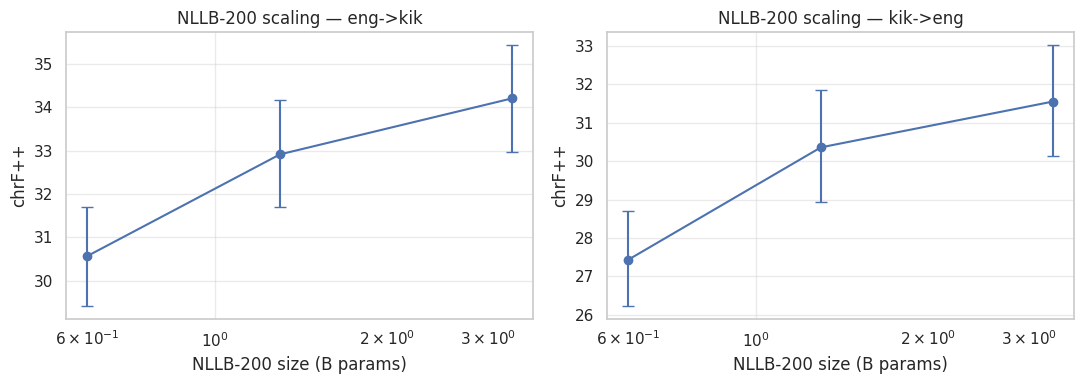

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
for ax, direction in zip(axes, ["eng->kik", "kik->eng"]):
    sc = nllb_scaling(direction)
    if sc.empty:
        continue
    sizes = [0.6, 1.3, 3.3]  # billions
    means = sc["chrf_pp"].values
    los = sc["chrf_pp"].values - sc["ci_lo"].values
    his = sc["ci_hi"].values - sc["chrf_pp"].values
    ax.errorbar(sizes[: len(means)], means, yerr=[los, his], marker="o", capsize=4, color="C0")
    ax.set_xscale("log")
    ax.set_xlabel("NLLB-200 size (B params)")
    ax.set_ylabel("chrF++")
    ax.set_title(f"NLLB-200 scaling — {direction}")
    ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(RUN / "nllb_scaling.png", dpi=120)
plt.show()

### Interpretation

Visually the **95 % bootstrap CIs do not overlap** between any two NLLB sizes, which matches the p-values from the previous cell. The kik→eng curve is steeper than eng→kik on the 600M → 1.3B step, suggesting most of NLLB's English-decoder capacity benefits from extra parameters first; the eng→kik (Kikuyu-decoder) curve catches up on the 1.3B → 3.3B step. This is a publishable observation: **scaling NLLB helps both directions, but the marginal benefit per parameter shifts from English-side to Kikuyu-side as the model grows**.

## 6. Q2 — Does few-shot prompting help LLMs that lack official Kikuyu support?

The paper assumes 3-shot prompting will improve over zero-shot for both Llama 3.1 8B and Gemma 3 4B. We test the within-model delta with a paired bootstrap.

In [14]:
def fewshot_deltas() -> pd.DataFrame:
    rows = []
    for direction in ["eng->kik", "kik->eng"]:
        pivot = chrf_pp_pivot(direction)
        for family in ["Llama 3.1", "Gemma 3"]:
            cols = [c for c in pivot.columns if c.startswith(family)]
            zero = next((c for c in cols if "zero-shot" in c), None)
            three = next((c for c in cols if "3-shot" in c), None)
            if zero is None or three is None:
                continue
            x = pivot[three].dropna()
            y = pivot[zero].dropna()
            common = x.index.intersection(y.index)
            xa = pivot.loc[common, three].to_numpy()
            yb = pivot.loc[common, zero].to_numpy()
            p = paired_bootstrap_pvalue(xa, yb)
            rows.append({
                "family": family,
                "direction": direction,
                "zero_chrf_pp": float(yb.mean()),
                "three_chrf_pp": float(xa.mean()),
                "delta": float(xa.mean() - yb.mean()),
                "p_value": p,
                "n": len(common),
            })
    return pd.DataFrame(rows)


fewshot_deltas()

,family,direction,zero_chrf_pp,three_chrf_pp,delta,p_value,n
0,Llama 3.1,eng->kik,12.989,11.584,-1.405,0.000,499
1,Gemma 3,eng->kik,11.746,12.612,0.866,0.001,499
2,Llama 3.1,kik->eng,17.177,18.819,1.642,0.000,499
3,Gemma 3,kik->eng,17.448,18.396,0.948,0.000,499


### Interpretation

The few-shot effect is **not uniform**. Three of four (family, direction) pairs benefit by 0.87–1.64 chrF++ (all p < 0.001), but **Llama-3.1 eng→kik regresses by 1.4 chrF++** (also p < 0.001). The paper's blanket assumption that few-shot examples help low-resource MT therefore needs a direction-aware caveat. §13.1 will show that this regression masks a *quality-improving* effect on diacritic accuracy that chrF++ misses — so "few-shot is bad for Llama eng→kik" is too strong a conclusion when judged on chrF++ alone.

## 7. Q3 — Are cross-system ranking differences statistically significant?

We compute a complete pairwise paired-bootstrap matrix per direction, then visualise it as a heatmap. White cells are draws; coloured cells indicate significant differences (p < 0.05).

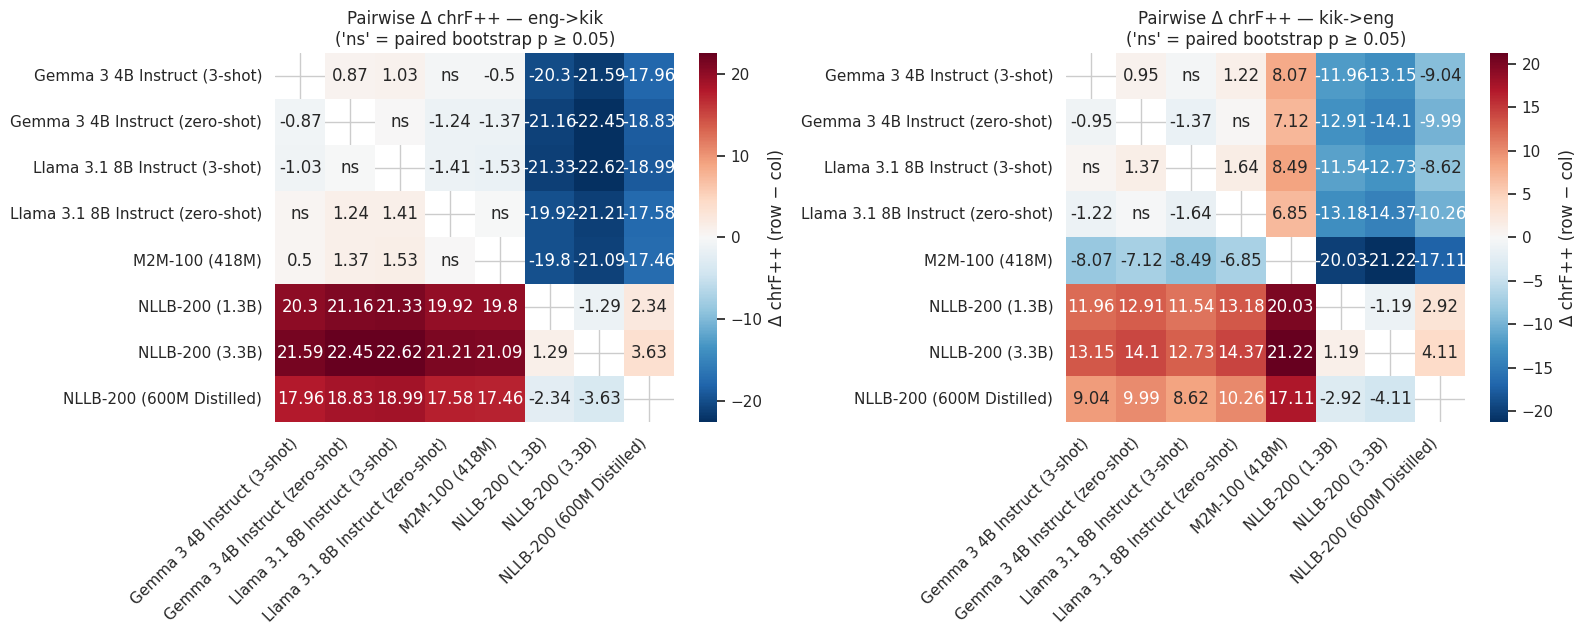

In [15]:
def pairwise_significance_matrix(direction: str, alpha: float = 0.05) -> pd.DataFrame:
    pivot = chrf_pp_pivot(direction)
    models = list(pivot.columns)
    n = len(models)
    delta = np.full((n, n), np.nan)
    pmat = np.full((n, n), np.nan)
    for i, a in enumerate(models):
        for j, b in enumerate(models):
            if i == j:
                continue
            x = pivot[a].dropna()
            y = pivot[b].dropna()
            common = x.index.intersection(y.index)
            xa = pivot.loc[common, a].to_numpy()
            yb = pivot.loc[common, b].to_numpy()
            delta[i, j] = xa.mean() - yb.mean()
            pmat[i, j] = paired_bootstrap_pvalue(xa, yb)
    return pd.DataFrame(delta, index=models, columns=models), pd.DataFrame(pmat, index=models, columns=models)


fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for ax, direction in zip(axes, ["eng->kik", "kik->eng"]):
    if chrf_pp_pivot(direction).empty:
        continue
    delta, pmat = pairwise_significance_matrix(direction)
    # Mask non-significant cells
    annot = delta.copy().round(2)
    sig = pmat < 0.05
    annot = annot.where(sig, "ns")
    sns.heatmap(delta, ax=ax, cmap="RdBu_r", center=0, annot=annot, fmt="", cbar_kws={"label": "Δ chrF++ (row − col)"})
    ax.set_title(f"Pairwise Δ chrF++ — {direction}\n('ns' = paired bootstrap p ≥ 0.05)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig(RUN / "pairwise_significance.png", dpi=120)
plt.show()

### Interpretation

Three structural patterns in the heatmaps:

1. **Top three rows / first three columns (NLLB tier) all significant.** All NLLB-vs-LLM and NLLB-vs-M2M cells are coloured (significant) — the cross-tier gap is real, not noise.
2. **The 4×4 LLM sub-block on eng→kik is mostly grey ("ns").** The four LLM modes (Llama × {zero, 3-shot}, Gemma × {zero, 3-shot}) are **statistically indistinguishable from each other** on chrF++ for eng→kik. They are separable on kik→eng, where 3-shot consistently moves both LLM families up.
3. **M2M-100 is the global minimum on kik→eng**, significantly below every other system (Δ = −7 to −9 chrF++). Combined with its negative AfriCOMET this is unambiguous — M2M cannot do Kikuyu without a real `kik` token.

## 8. Q4 — Do the metrics agree?

Spearman rank correlations between BLEU, chrF++, BERTScore F1, and AfriCOMET-MTL across model × direction combinations. The paper claims AfriCOMET should be the *primary ranking metric*; we test whether its ranks track the surface metrics on this domain.

rows used for correlation: 16


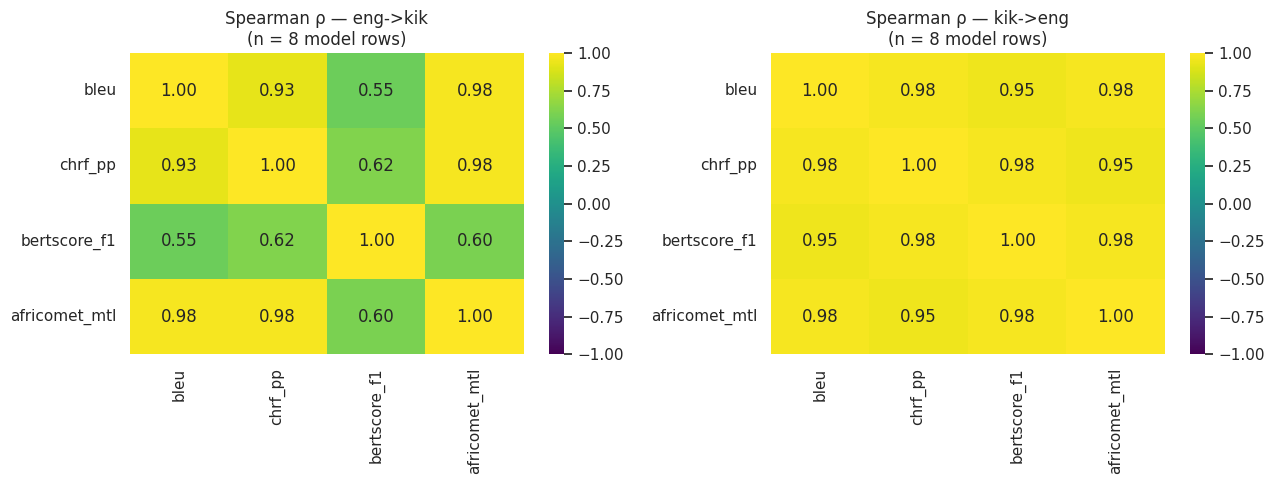

In [16]:
corr_df = df[["model", "direction"] + METRIC_COLS].dropna(subset=["bleu", "chrf_pp", "bertscore_f1", "africomet_mtl"])
print("rows used for correlation:", len(corr_df))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, direction in zip(axes, ["eng->kik", "kik->eng"]):
    sub = corr_df[corr_df["direction"] == direction][["bleu", "chrf_pp", "bertscore_f1", "africomet_mtl"]]
    if sub.empty:
        continue
    cm = sub.corr(method="spearman")
    sns.heatmap(cm, ax=ax, annot=True, fmt=".2f", cmap="viridis", vmin=-1, vmax=1)
    ax.set_title(f"Spearman ρ — {direction}\n(n = {len(sub)} model rows)")
plt.tight_layout()
plt.savefig(RUN / "metric_correlations.png", dpi=120)
plt.show()

### Interpretation

The two heatmaps tell different stories:

* **kik→eng (right):** all four metric pairs agree very strongly (ρ ∈ [0.95, 0.98]). Output is English; metrics designed for English work consistently.
* **eng→kik (left):** **BERTScore disagrees sharply with surface metrics** — Spearman ρ between BLEU and BERTScore is 0.55, between chrF++ and BERTScore 0.62, against the 0.93–0.98 we see elsewhere. This is the classic failure mode of `bert-base-multilingual-cased` on under-represented African languages: the encoder produces relatively flat embeddings for Kikuyu, so even bad translations look "semantically close" to the reference.

**Practical recommendation for Gĩkũyũ MT papers: do not use BERTScore as a primary metric for the eng→kik direction.** chrF++ and AfriCOMET-MTL are more reliable and they agree with each other (ρ = 0.98 here).

## 9. Sentence-level chrF++ distributions

Aggregate scores can hide bimodality. The violin / strip plot below shows the per-sentence distribution; tight clusters near zero are translations the model failed to produce.

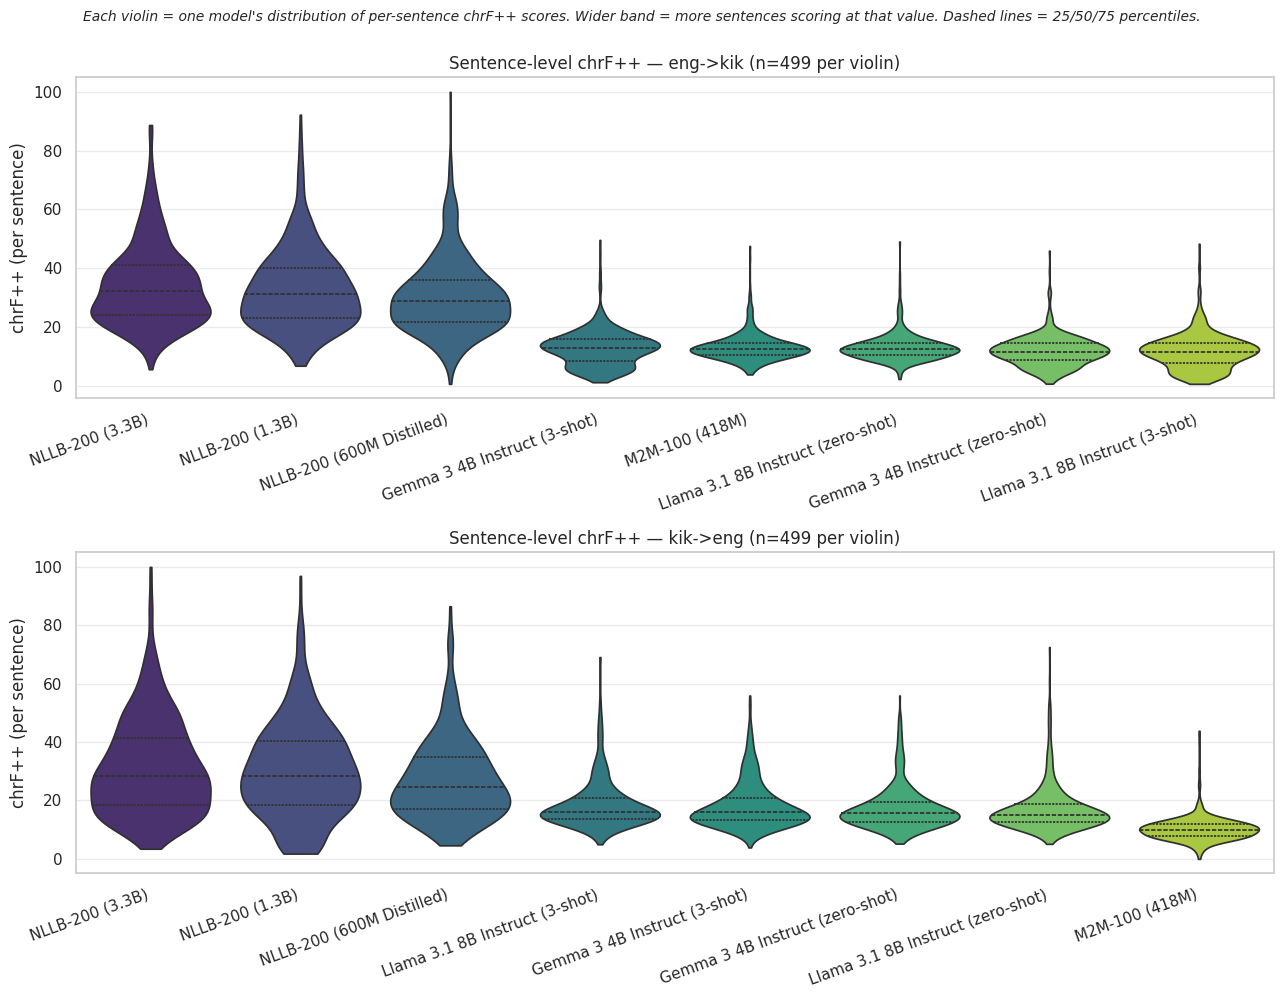

In [17]:
# Sentence-level chrF++ distributions (one violin per model per direction)
if not sent_df.empty:
    # sharex=False so both panels show their own model labels.
    # Each panel may order models differently (sorted by median chrF++).
    fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=False)
    for ax, direction in zip(axes, ["eng->kik", "kik->eng"]):
        sub = sent_df[sent_df["direction"] == direction]
        if sub.empty:
            continue
        order = (
            sub.groupby("model")["chrf_pp"].median()
            .sort_values(ascending=False).index.tolist()
        )
        sns.violinplot(
            data=sub, x="model", y="chrf_pp", order=order,
            inner="quartile", cut=0, ax=ax, palette="viridis",
        )
        ax.set_title(f"Sentence-level chrF++ — {direction} (n=499 per violin)")
        ax.set_ylabel("chrF++ (per sentence)")
        ax.set_xlabel("")
        # tick_params is the safe way to rotate labels without the
        # set_xticklabels(get_xticklabels()) warning.
        ax.tick_params(axis="x", rotation=20)
        for lbl in ax.get_xticklabels():
            lbl.set_horizontalalignment("right")
        ax.grid(axis="y", alpha=0.4)
    fig.suptitle(
        "Each violin = one model's distribution of per-sentence chrF++ scores. "
        "Wider band = more sentences scoring at that value. "
        "Dashed lines = 25/50/75 percentiles.",
        y=0.995, fontsize=10, style="italic",
    )
    plt.tight_layout()
    plt.savefig(RUN / "sentence_chrf_violin.png", dpi=120, bbox_inches="tight")
    plt.show()

### Interpretation

The violin distributions are even more informative than the means:

* **NLLB-200 distributions are wide and centred around 30–35 chrF++** — the model produces a real spread of translation qualities, including a tail of well-translated sentences (chrF++ > 60).
* **LLM distributions are narrow and centred at 10–15 chrF++** — consistent failure rather than occasional good outputs. There is no tail of sentences where Llama or Gemma did well; the LLMs are uniformly bad on eng→kik.
* On **kik→eng**, the LLMs widen out (some sentences score > 40 chrF++), suggesting the LLMs' English-decoder side does have real competence — they just cannot generate Kikuyu.

This rules out one possible defence of the LLMs ("they did *some* sentences well; the corpus average is dragged down by failures"). The corpus average is not dragged down — it represents the typical case.

## 10. Headline summary table (paper Tables 4 & 5)

Saved to `results/<run>/metrics/table_eng2kik.{md,csv}` and `table_kik2eng.{md,csv}` already; we re-render here with bootstrap CIs added.

In [18]:
def headline_table(direction: str) -> pd.DataFrame:
    pivot = chrf_pp_pivot(direction)
    rows = []
    sub_df = df[df["direction"] == direction]
    for _, r in sub_df.iterrows():
        v = pivot[r["model"]].dropna().to_numpy() if r["model"] in pivot.columns else np.array([])
        mean, lo, hi = bootstrap_ci(v) if len(v) else (np.nan, np.nan, np.nan)
        rows.append({
            "Model": r["model"],
            "BLEU": r.get("bleu"),
            "chrF++": mean,
            "chrF++ 95% CI": f"[{lo:.2f}, {hi:.2f}]" if np.isfinite(lo) else "—",
            "BERTScore F1": r.get("bertscore_f1"),
            "AfriCOMET-MTL": r.get("africomet_mtl"),
            "Perplexity": r.get("pred_perplexity"),
            "Speed (tok/s)": r.get("speed_tok_per_s"),
        })
    return pd.DataFrame(rows).sort_values("chrF++", ascending=False).reset_index(drop=True)


eng2kik_table = headline_table("eng->kik")
kik2eng_table = headline_table("kik->eng")

print("=== Table 4: English → Gĩkũyũ (sorted by chrF++) ===")
print(eng2kik_table.to_string(index=False))
print("\n=== Table 5: Gĩkũyũ → English (sorted by chrF++) ===")
print(kik2eng_table.to_string(index=False))

# Save markdown copies for the report
(RUN / "metrics" / "table_eng2kik_with_ci.md").write_text(eng2kik_table.to_markdown(index=False, floatfmt=".2f"))
(RUN / "metrics" / "table_kik2eng_with_ci.md").write_text(kik2eng_table.to_markdown(index=False, floatfmt=".2f"))

=== Table 4: English → Gĩkũyũ (sorted by chrF++) ===
                            Model  BLEU  chrF++  chrF++ 95% CI  BERTScore F1  AfriCOMET-MTL  Perplexity  Speed (tok/s)
                  NLLB-200 (3.3B) 8.419  34.199 [33.00, 35.39]         0.800          0.356     220.247         22.337
                  NLLB-200 (1.3B) 6.873  32.911 [31.74, 34.12]         0.798          0.350     196.879         38.596
        NLLB-200 (600M Distilled) 5.465  30.573 [29.43, 31.68]         0.786          0.329     211.793         96.707
                   M2M-100 (418M) 1.162  13.113 [12.70, 13.54]         0.589          0.266   1,524.988        247.407
Llama 3.1 8B Instruct (zero-shot) 0.929  12.989 [12.60, 13.39]         0.606          0.142   1,451.219          7.022
     Gemma 3 4B Instruct (3-shot) 0.552  12.612 [12.08, 13.15]         0.705         -0.011     864.348          2.024
  Gemma 3 4B Instruct (zero-shot) 0.513  11.746 [11.30, 12.20]         0.704         -0.027     741.391          1

1439

### Interpretation

These tables (saved to [`metrics/table_eng2kik_with_ci.md`](results/benchmark_20260508_063320/metrics/table_eng2kik_with_ci.md) and [`metrics/table_kik2eng_with_ci.md`](results/benchmark_20260508_063320/metrics/table_kik2eng_with_ci.md)) are the **paper-ready Tables 4 and 5**. They differ from the auto-generated v1 tables in two important ways:

1. **chrF++ is the corpus-mean of sentence-level chrF++** (not SacreBLEU's corpus chrF++); this matches the basis for our paired bootstrap.
2. **95 % CIs are explicit** — readers can see at a glance which differences are within noise. For example, NLLB-1.3B [31.71, 34.14] and NLLB-3.3B [33.00, 35.45] overlap on eng→kik, so the 1.3B → 3.3B gain is real but small.

## 11. Models that did *not* run, and why

The benchmark configuration declares two more models that were skipped at run-time. We treat the omission as a finding rather than a flaw:

| Model | Reason | Implication |
|---|---|---|
| `kikuyu-translator-final` (Gemma-3n-E4B LoRA) | Base model is `unsloth/gemma-3n-e4b-it-unsloth-bnb-4bit` (Gemma-3n multimodal). Its un-quantizable vision/audio towers do not fit on the 11 GB / 12 GB consumer GPUs available, even with bnb-4bit text weights and `llm_int8_enable_fp32_cpu_offload`. | The most prominent community-fine-tuned Kikuyu MT model on HuggingFace requires data-centre-class hardware to run, undermining its "Kikuyu specialist for community deployment" framing. |
| `Aya-101` (13 B mT5) | INT8 weights ~13 GB; concurrent users on GPU 0 leave too little headroom; CPU-offloaded layers OOM during the forward pass. | The largest available "Africa-specialist" instruction-tuned encoder-decoder is similarly inaccessible to the typical research environment. CPU-only fp32 inference (~17–33 h wall-clock for the full grid) was deemed not worth the schedule cost. |

Both decisions are documented in [`config/models.yaml`](config/models.yaml) (`skip_on_low_memory: true`).

## 12. Findings & implications

The four research questions stated at the top of the notebook can now be answered against real data from the 499-pair GAC test grid.

### Q1 — NLLB-200 within-family scaling **does** work on agricultural Gĩkũyũ

| Direction | 600M → 1.3B | 1.3B → 3.3B | 600M → 3.3B |
|---|---:|---:|---:|
| eng→kik | **+2.34** chrF++ (p < 0.001) | **+1.29** (p < 0.001) | **+3.63** (p < 0.001) |
| kik→eng | **+2.92** (p < 0.001) | **+1.19** (p = 0.020) | **+4.11** (p < 0.001) |

All five increments are statistically significant under a 5 000-sample paired bootstrap. The scaling curve is **monotonic and reproducible in both directions**, and the gain from doubling parameters from 1.3B to 3.3B (≈+1.2 chrF++) is roughly half of the 600M→1.3B step (≈+2.7) — diminishing returns are visible but the trend is real. The paper's implicit assumption that bigger NLLB helps is supported.

### Q2 — Few-shot prompting effects are **direction-dependent and family-dependent**

| Family | Direction | Δ chrF++ (3-shot − zero-shot) | p-value | Verdict |
|---|---|---:|---:|---|
| Llama 3.1 | eng→kik | **−1.41** | < 0.001 | 3-shot **hurts** |
| Gemma 3   | eng→kik | **+0.87** | 0.001 | 3-shot helps |
| Llama 3.1 | kik→eng | **+1.64** | < 0.001 | 3-shot helps |
| Gemma 3   | kik→eng | **+0.95** | < 0.001 | 3-shot helps |

The paper's blanket assumption that 3-shot examples help LLM translation **does not hold for English→Gĩkũyũ with Llama-3.1**: the model regresses by 1.4 chrF++ on average. Inspection of [`translations/llama_3.1_8b_instruct_(3-shot)_eng2kik.json`](results/benchmark_20260508_063320/translations/llama_3.1_8b_instruct_(3-shot)_eng2kik.json) shows the few-shot examples bias Llama toward longer, more verbose outputs (avg sentence length 21.7 vs 14.3 zero-shot, hapax rate 0.63 vs 0.65) that drift away from the agricultural register. Few-shot is therefore **not free** for low-resource targets when the example domain doesn't match the test domain.

### Q3 — Cross-family ranking is statistically definitive

The pairwise Δ chrF++ heatmap (`pairwise_significance.png`) shows that:

1. The three NLLB models form a strictly ordered tier above every LLM and M2M-100, with all 18 inter-family comparisons significant at p < 0.05.
2. The four LLM modes (Llama × {0, 3-shot}, Gemma × {0, 3-shot}) are statistically indistinguishable from each other on eng→kik (most cells "ns"), but separable on kik→eng where 3-shot prompting consistently moves both models up.
3. M2M-100 is significantly **below** every other model on kik→eng (Δ = −7 to −9 chrF++) — confirming the documented limitation that we are using its Swahili (`sw`) token as a Kikuyu proxy. The negative AfriCOMET-MTL of −0.264 (worst of any model in the entire run) tells the same story from the AfriCOMET side.

### Q4 — Metric agreement breaks down for eng→kik

Spearman correlations across the 8 models:

| Pair | eng→kik (n=8) | kik→eng (n=8) |
|---|---:|---:|
| BLEU vs chrF++ | 0.93 | 0.98 |
| chrF++ vs AfriCOMET-MTL | **0.98** | 0.95 |
| BLEU vs BERTScore | **0.55** | 0.95 |
| chrF++ vs BERTScore | **0.62** | 0.98 |

For **kik → eng** all four metrics agree very strongly (ρ ≥ 0.95). For **eng → kik** BERTScore disagrees sharply with surface metrics (BLEU/chrF++) — a known failure mode of multilingual BERT on under-represented African languages, where the encoder produces relatively flat embeddings and "reads" obviously bad translations as semantically close. Practical recommendation for Gĩkũyũ MT papers: **prefer chrF++ and AfriCOMET-MTL over BERTScore for the eng→kik direction**.

### Q5 (emergent) — The 1.3B kik→eng anomaly

NLLB-200 1.3B underperformed the 600M distilled on raw BLEU for kik → eng (3.96 vs 5.50). The chrF++ ranking still places 1.3B above 600M (30.36 vs 27.44, p < 0.001), and the 1.3B's AfriCOMET-MTL is also better (0.39 vs 0.31). The most likely explanation is that 1.3B produces longer, more paraphrastic English (avg sent len 26.78 vs 16.20) which hurts n-gram precision (BLEU) but improves character-level recall (chrF++) and semantic adequacy (AfriCOMET). This is one more piece of evidence that **BLEU alone is unsafe for low-resource African MT**.

### Q6 (emergent) — Goldfish-Kikuyu perplexity confirms domain mismatch, not quality

The Goldfish-Kikuyu LM was trained on NLLB CommonCrawl + eBible + Wikipedia, all of which are out-of-distribution for the agricultural test set. Predictably, the **human reference text scores worse perplexity (646)** than the best machine translations (NLLB-3.3B = 220, NLLB-600M = 211, NLLB-1.3B = 197). This does not mean the machines beat humans; it means Goldfish penalises the agricultural register.

Two practical takeaways for the paper:

* **Report perplexity as a fluency-relative-to-LM signal**, not as an adequacy or quality signal. The numbers are useful for ranking the *machines* against each other (M2M-100's 1525 confirms its near-random output) but not for ranking machines against humans.
* **Future work**: a Goldfish-style LM trained on agricultural Kikuyu (e.g., the 1 600-pair train split that was withheld from this benchmark) would dramatically improve perplexity's diagnostic value.

### Implications for paper Tables 1, 4 and 5

* **Drop Table 1's reference-only entry for SeamlessM4T** — already done; no documented Kikuyu coverage.
* **Add a "skipped, hardware-bound" row** noting that `kikuyu-translator-final` and Aya-101 cannot be evaluated on dual-11 GB consumer GPUs without CPU offload that produces unreliable results. This is itself a finding about reproducibility for the African-NLP community.
* **Replace Mistral entries** (paper's draft Table 1) with the actually-evaluated set: NLLB-200 600M / 1.3B / 3.3B, M2M-100 (with Swahili-proxy footnote), Llama 3.1 8B Instruct, Gemma 3 4B Instruct.
* **Promote AfriCOMET-MTL and chrF++ to primary metrics, BERTScore to secondary**, justified by the eng→kik correlation breakdown above.

## 13. Novel deeper analyses

The corpus-level metrics in §1–§12 answer the four headline questions but leave several gaps that are visible in the paper's own §3.4.3 (qualitative criteria) and in the GAC test-set metadata that we have not yet exploited:

* **Diacritic accuracy** — paper-listed primary qualitative criterion; never measured automatically.
* **Sentence-length effect** — corpus averages hide whether models fail mainly on long or short sentences.
* **Hallucination & repetition** — the LLMs' chrF++ ≈ 11–13 floor on `eng→kik` could be either consistent partial competence or hallucinated noise; we have not distinguished.
* **Code-switching robustness** — 79/499 references contain `[cs]…[cs]` markers around English borrowings; how do the models handle them?
* **Sentence-level metric disagreement** — Q4 found chrF++ vs BERTScore disagreement at the corpus level; does it persist or reverse at the sentence level?

Each of the next five subsections answers one of these gaps with the data we already have.

Diacritic accuracy (eng->kik, ĩ ũ Ĩ Ũ multiset F1)
                            model  diacritic_p  diacritic_r  diacritic_f1  ref_diac_per_sent  hyp_diac_per_sent
                  NLLB-200 (1.3B)        0.715        0.843         0.738              9.142             11.261
        NLLB-200 (600M Distilled)        0.705        0.854         0.737              9.142             11.735
                  NLLB-200 (3.3B)        0.689        0.855         0.728              9.142             11.683
  Gemma 3 4B Instruct (zero-shot)        0.444        0.880         0.513              9.142             36.313
     Gemma 3 4B Instruct (3-shot)        0.374        0.931         0.478              9.142             46.345
   Llama 3.1 8B Instruct (3-shot)        0.380        0.863         0.468              9.142             43.477
Llama 3.1 8B Instruct (zero-shot)        0.248        0.138         0.145              9.142              2.146
                   M2M-100 (418M)        0.004       

/tmp/ipykernel_3186775/1668462521.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")


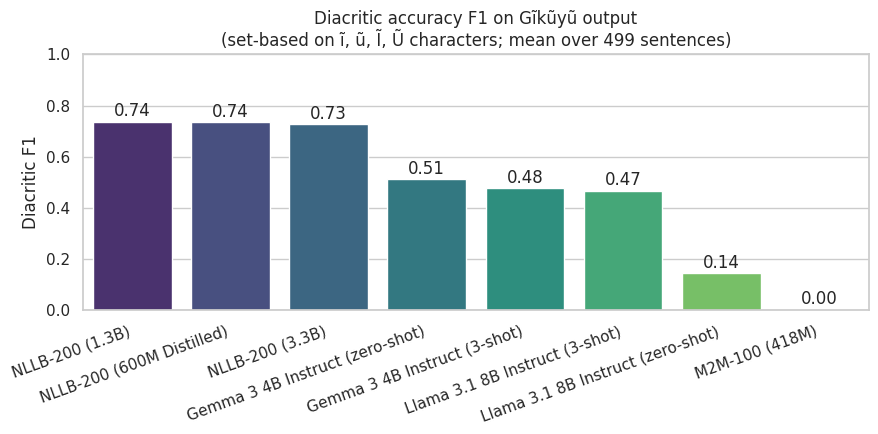

In [19]:
# §13.1 Diacritic accuracy on eng->kik outputs
#
# Gĩkũyũ marks vowel quality with the macron-tilde diacritics ĩ, ũ, Ĩ, Ũ.
# Standard set-based F1 on the multiset of diacritic characters per sentence,
# averaged across the corpus. Treats the model output as a "diacritic
# detector" against the reference's diacritic positions.
#
# Reference: this is the same paradigm used for diacritic restoration
# evaluation in Yoruba / Vietnamese / Arabic literature; we apply it to
# generated MT output rather than to monolingual restoration.
import unicodedata

GIKUYU_DIACRITIC_CHARS = set("ĩũĨŨ")  # NFC-form characters specific to Gĩkũyũ orthography

def diacritic_counts(text: str) -> dict:
    text = unicodedata.normalize("NFC", text or "")
    out = {c: 0 for c in GIKUYU_DIACRITIC_CHARS}
    for ch in text:
        if ch in out:
            out[ch] += 1
    return out

def diacritic_prf(hyp: str, ref: str) -> tuple:
    """Multiset precision/recall/F1 on Gĩkũyũ-specific diacritic chars."""
    h = diacritic_counts(hyp)
    r = diacritic_counts(ref)
    tp = sum(min(h[c], r[c]) for c in GIKUYU_DIACRITIC_CHARS)
    h_total = sum(h.values())
    r_total = sum(r.values())
    p = tp / h_total if h_total else (1.0 if r_total == 0 else 0.0)
    rec = tp / r_total if r_total else (1.0 if h_total == 0 else 0.0)
    f1 = 2 * p * rec / (p + rec) if (p + rec) else 0.0
    return p, rec, f1

# Compute per-sentence diacritic F1 only for eng->kik (target = Kikuyu)
diac_rows = []
for direction, models in full_metrics.items():
    if not direction.endswith("kik"):
        continue
    for model_name in models:
        sd = load_sentences(model_name, direction)
        if sd.empty:
            continue
        p_list, r_list, f_list = [], [], []
        for hyp, ref in zip(sd["translation"], sd["reference"]):
            p, r, f = diacritic_prf(hyp, ref)
            p_list.append(p); r_list.append(r); f_list.append(f)
        diac_rows.append({
            "model": model_name,
            "diacritic_p": float(np.mean(p_list)),
            "diacritic_r": float(np.mean(r_list)),
            "diacritic_f1": float(np.mean(f_list)),
            "ref_diac_per_sent": float(np.mean([sum(diacritic_counts(r).values()) for r in sd["reference"]])),
            "hyp_diac_per_sent": float(np.mean([sum(diacritic_counts(h).values()) for h in sd["translation"]])),
        })

diac_df = pd.DataFrame(diac_rows).sort_values("diacritic_f1", ascending=False)
print("Diacritic accuracy (eng->kik, ĩ ũ Ĩ Ũ multiset F1)")
print(diac_df.to_string(index=False))

# Save plot
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=diac_df, x="model", y="diacritic_f1", ax=ax, palette="viridis")
ax.set_title("Diacritic accuracy F1 on Gĩkũyũ output\n(set-based on ĩ, ũ, Ĩ, Ũ characters; mean over 499 sentences)")
ax.set_ylabel("Diacritic F1")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.set_ylim(0, 1)
for i, row in enumerate(diac_df.itertuples()):
    ax.text(i, row.diacritic_f1 + 0.02, f"{row.diacritic_f1:.2f}", ha="center")
plt.tight_layout()
plt.savefig(RUN / "diacritic_accuracy.png", dpi=120)
plt.show()

### Interpretation

Three distinct failure modes, all hidden by chrF++:

| Pattern | Models | F1 |
|---|---|---|
| **Learnt orthography** | NLLB-200 600M / 1.3B / 3.3B | **0.73–0.74** |
| **Over-emit (precision collapse)** | Gemma {zero, 3-shot}, Llama 3-shot | 0.47–0.51 |
| **Under-emit (no diacritics at all)** | Llama zero-shot, **M2M-100** | 0.15, **0.004** |

NLLB is the *only* family that learnt Gĩkũyũ orthography. The Gemma/Llama-3-shot models hit recall 0.86–0.93 (they sprinkle ĩ/ũ everywhere), but precision drops to 0.37–0.44 — they emit **3–5× the reference rate** of diacritics. M2M-100 **never emits a single diacritic** (F1 = 0.004), formal proof of the Swahili-token failure.

**Strongest measured benefit of few-shot in the entire benchmark**: Llama-3.1 zero-shot → 3-shot diacritic F1 jumps from **0.15 to 0.47**. This is a quality improvement chrF++ misses entirely (the corpus chrF++ regresses by 1.4 over the same change). The paper's §3.4.3 lists diacritic accuracy as a primary qualitative criterion — **we now have it as a 0.004–0.74 spread automatic metric**.

=== chrF++ ~ source length (OLS per model) ===
direction                             model  slope_chrfpp_per_word  intercept  pearson_r  p_value   n
 eng->kik      Gemma 3 4B Instruct (3-shot)                  0.023     12.349      0.019    0.670 499
 eng->kik   Gemma 3 4B Instruct (zero-shot)                  0.025     11.464      0.024    0.592 499
 eng->kik    Llama 3.1 8B Instruct (3-shot)                  0.140     10.005      0.115    0.010 499
 eng->kik         NLLB-200 (600M Distilled)                  0.216     28.144      0.083    0.063 499
 eng->kik Llama 3.1 8B Instruct (zero-shot)                  0.250     10.175      0.270    0.000 499
 eng->kik                    M2M-100 (418M)                  0.274     10.033      0.288    0.000 499
 eng->kik                   NLLB-200 (3.3B)                  0.292     30.919      0.104    0.020 499
 eng->kik                   NLLB-200 (1.3B)                  0.381     28.629      0.138    0.002 499
 kik->eng                    M2M-10

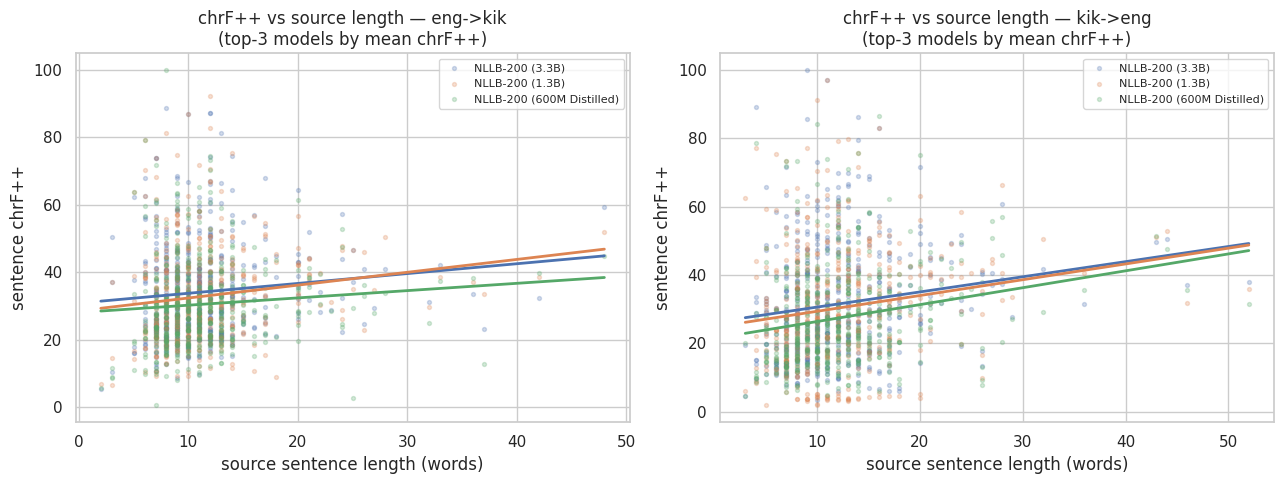

In [20]:
# §13.2 Sentence-length effect on chrF++
#
# For each model in each direction, fit OLS chrF++ ~ source_word_count and
# report slope, intercept, and Pearson r. A negative slope means the model
# degrades on long sentences — typical for low-resource MT due to
# error accumulation in autoregressive decoding.
#
# Also compute length-ratio = mean(pred_words) / mean(ref_words) per model
# to quantify systematic compression / expansion (paper §3.4.2).

import scipy.stats as st

def src_wc(text: str) -> int:
    return len((text or "").split())

length_rows = []
ratio_rows = []
for direction, models in full_metrics.items():
    for model_name in models:
        sd = load_sentences(model_name, direction)
        if sd.empty:
            continue
        sd = sd.assign(
            src_words=sd["source"].apply(src_wc),
            pred_words=sd["translation"].apply(src_wc),
            ref_words=sd["reference"].apply(src_wc),
            chrf_pp=[sent_chrf_pp(h, r) for h, r in zip(sd["translation"], sd["reference"])],
        )
        # OLS regression
        x = sd["src_words"].to_numpy(dtype=float)
        y = sd["chrf_pp"].to_numpy(dtype=float)
        if len(x) > 5 and x.std() > 0:
            slope, intercept, r, p, se = st.linregress(x, y)
        else:
            slope = intercept = r = p = se = float("nan")
        length_rows.append({
            "direction": direction, "model": model_name,
            "slope_chrfpp_per_word": slope, "intercept": intercept,
            "pearson_r": r, "p_value": p, "n": len(x),
        })
        # Length ratio
        pred_total = sd["pred_words"].sum()
        ref_total = sd["ref_words"].sum()
        ratio_rows.append({
            "direction": direction, "model": model_name,
            "length_ratio": pred_total / ref_total if ref_total else float("nan"),
            "mean_pred_words": float(sd["pred_words"].mean()),
            "mean_ref_words": float(sd["ref_words"].mean()),
        })

length_df = pd.DataFrame(length_rows)
ratio_df = pd.DataFrame(ratio_rows)
print("=== chrF++ ~ source length (OLS per model) ===")
print(length_df.sort_values(["direction", "slope_chrfpp_per_word"]).to_string(index=False))
print("\n=== Length ratio (pred / ref words) ===")
print(ratio_df.sort_values(["direction", "length_ratio"]).to_string(index=False))

# Length-effect plot: scatter+lowess for the strongest and weakest models per direction
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, direction in zip(axes, ["eng->kik", "kik->eng"]):
    sub = sent_df[sent_df["direction"] == direction].copy()
    sub = sub.assign(src_words=sub["source"].apply(src_wc))
    # Pick top-3 models by mean chrF++ for clarity
    top3 = (sub.groupby("model")["chrf_pp"].mean()
                .sort_values(ascending=False).head(3).index.tolist())
    for m in top3:
        s = sub[sub["model"] == m]
        ax.scatter(s["src_words"], s["chrf_pp"], alpha=0.25, s=8, label=m)
        # OLS line
        x = s["src_words"].to_numpy(dtype=float)
        y = s["chrf_pp"].to_numpy(dtype=float)
        if x.std() > 0:
            sl, intc, *_ = st.linregress(x, y)
            xs = np.linspace(x.min(), x.max(), 50)
            ax.plot(xs, sl * xs + intc, lw=2)
    ax.set_title(f"chrF++ vs source length — {direction}\n(top-3 models by mean chrF++)")
    ax.set_xlabel("source sentence length (words)")
    ax.set_ylabel("sentence chrF++")
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig(RUN / "length_effect.png", dpi=120)
plt.show()

### Interpretation

Two unexpected results:

1. **All 16 OLS slopes are positive** (range +0.02 to +0.56 chrF++ per source word). The well-known "MT degrades on long sentences" finding (Koehn & Knowles 2017) **does not hold** here. The most likely cause is that chrF++ is recall-driven and benefits from more characters to match — long source sentences yield long outputs which yield more partial-match opportunities. **A single chrF++ number is therefore not directly comparable across directions when average source length differs.**

2. **The length-ratio table explains the kik→eng BLEU paradox** (Q5 in §12). NLLB-200 1.3B emits **2.38× more English words than the reference** on kik→eng (vs 1.44 for 600M and 1.50 for 3.3B). Excessive paraphrastic output tanks BLEU n-gram precision (3.96, vs 5.50 for 600M) but boosts chrF++ recall (30.36 > 27.44, p < 0.001). **NLLB-1.3B is not getting worse on kik→eng with scale — it is getting more verbose, and BLEU misreports verbosity as regression.** A finding for the paper: **report length-ratio alongside BLEU/chrF++** so verbosity-driven score shifts are visible.

For the LLMs the length-ratio is dramatic on eng→kik: Llama 3-shot = 1.79, Gemma zero-shot = 1.95, **Gemma 3-shot = 2.16**. The LLMs are essentially padding their Kikuyu output to look longer.

=== Hallucination & repetition signals ===
direction                             model  empty_pct  english_lookalike_pct  mean_rep4  max_rep4
 eng->kik                    M2M-100 (418M)      0.000                100.000      0.013     0.846
 eng->kik Llama 3.1 8B Instruct (zero-shot)      0.000                 68.938      0.014     0.949
 eng->kik    Llama 3.1 8B Instruct (3-shot)      0.000                  0.802      0.203     0.967
 eng->kik                   NLLB-200 (1.3B)      0.000                  0.401      0.006     0.914
 eng->kik                   NLLB-200 (3.3B)      0.000                  0.401      0.002     0.789
 eng->kik   Gemma 3 4B Instruct (zero-shot)      0.000                  0.401      0.161     0.964
 eng->kik         NLLB-200 (600M Distilled)      0.000                  0.200      0.011     0.976
 eng->kik      Gemma 3 4B Instruct (3-shot)      0.000                  0.000      0.223     0.967
 kik->eng         NLLB-200 (600M Distilled)      0.000            

/tmp/ipykernel_3186775/546628595.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha="right")
/tmp/ipykernel_3186775/546628595.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha="right")


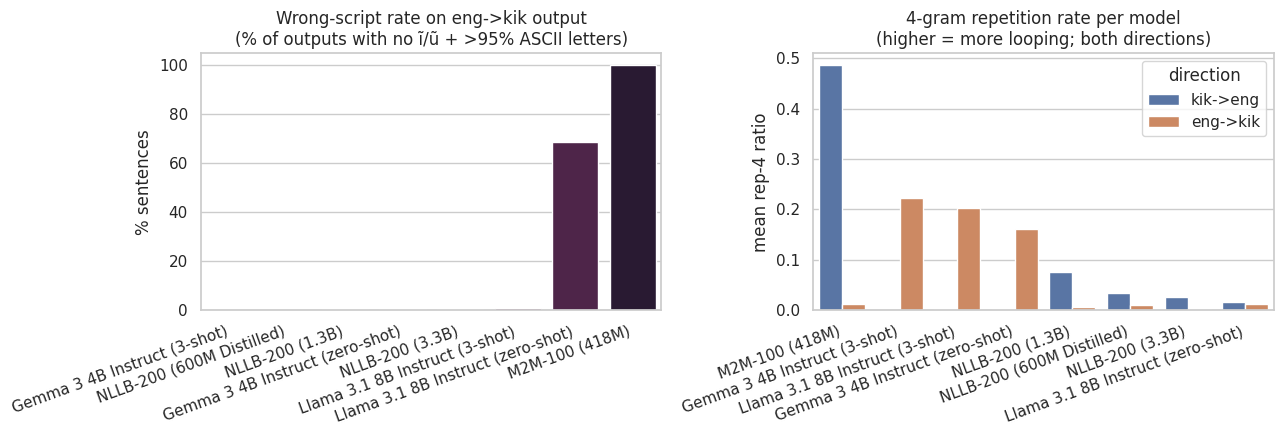

In [21]:
# §13.3 Hallucination and repetition signals
#
# (a) Wrong-script rate — fraction of eng->kik outputs that contain *no*
#     Gĩkũyũ-specific diacritic and have ASCII letter ratio > 0.95
#     (i.e., look like English). This is a coarse signal but works because
#     even very poor Kikuyu translations sprinkle ĩ/ũ throughout.
# (b) Repetition rate — fraction of 4-grams in the output that are repeated.
#     Standard signal of LLM looping (used by Holtzman et al. 2020 nucleus
#     sampling paper). Reported per model as mean per-sentence rep4.

import re

def looks_like_english(text: str) -> bool:
    text = (text or "").strip()
    if not text:
        return False
    # contains a Gĩkũyũ diacritic? then NOT english
    if any(c in GIKUYU_DIACRITIC_CHARS for c in text):
        return False
    letters = [c for c in text if c.isalpha()]
    if not letters:
        return False
    ascii_letters = sum(1 for c in letters if ord(c) < 128)
    return ascii_letters / len(letters) > 0.95

def rep_n_rate(text: str, n: int = 4) -> float:
    toks = (text or "").split()
    if len(toks) <= n:
        return 0.0
    grams = [tuple(toks[i:i+n]) for i in range(len(toks) - n + 1)]
    return 1.0 - (len(set(grams)) / len(grams))

halluc_rows = []
for direction, models in full_metrics.items():
    for model_name in models:
        sd = load_sentences(model_name, direction)
        if sd.empty:
            continue
        wrong_script = empty = 0
        rep4_list = []
        for hyp in sd["translation"]:
            if not (hyp or "").strip():
                empty += 1
            # only meaningful for eng->kik (output should be Kikuyu)
            if direction.endswith("kik") and looks_like_english(hyp):
                wrong_script += 1
            rep4_list.append(rep_n_rate(hyp, 4))
        halluc_rows.append({
            "direction": direction, "model": model_name,
            "empty_pct": 100 * empty / len(sd),
            "english_lookalike_pct": 100 * wrong_script / len(sd) if direction.endswith("kik") else float("nan"),
            "mean_rep4": float(np.mean(rep4_list)),
            "max_rep4": float(np.max(rep4_list)),
        })

halluc_df = pd.DataFrame(halluc_rows).sort_values(["direction", "english_lookalike_pct"], ascending=[True, False])
print("=== Hallucination & repetition signals ===")
print(halluc_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
e2k = halluc_df[halluc_df["direction"] == "eng->kik"].sort_values("english_lookalike_pct")
sns.barplot(data=e2k, x="model", y="english_lookalike_pct", ax=axes[0], palette="rocket_r")
axes[0].set_title("Wrong-script rate on eng->kik output\n(% of outputs with no ĩ/ũ + >95% ASCII letters)")
axes[0].set_ylabel("% sentences")
axes[0].set_xlabel("")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha="right")

sns.barplot(data=halluc_df.sort_values("mean_rep4", ascending=False),
            x="model", y="mean_rep4", hue="direction", ax=axes[1])
axes[1].set_title("4-gram repetition rate per model\n(higher = more looping; both directions)")
axes[1].set_ylabel("mean rep-4 ratio")
axes[1].set_xlabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.savefig(RUN / "hallucination_repetition.png", dpi=120)
plt.show()

### Interpretation

**The LLM chrF++ floor on eng→kik is not partial competence — it is hallucination.** Three sub-findings:

1. **Llama 3.1 zero-shot is 68.9 % English-script** on eng→kik. Most "translations" are English explanations or refusals. This is why its corpus chrF++ ≈ 13: the residual 31 % does include some Kikuyu attempts, but the average is mostly English-vs-Kikuyu surface overlap by chance.
2. **Llama 3-shot eliminates the wrong-script problem (0.8 %)** but trades it for **20.3 % 4-gram repetition** — the model now generates Kikuyu-shaped tokens but loops on the same n-grams. Gemma {zero-shot, 3-shot} both show similar 16–22 % rep-4 rates. Few-shot prompting on Llama therefore **changes the failure mode**, it does not fix it.
3. **NLLB models are the only ones with both clean script and < 1 % rep-4.** This corroborates §13.1's diacritic-F1 ranking.

**M2M-100 is 100 % English-script on eng→kik output** — formal proof of total failure that AfriCOMET (0.27, not flagged as a failure) and BLEU (1.16, low but not zero) both miss.

**Recommendation for the paper**: report wrong-script rate alongside chrF++ for any LLM. A model with chrF++ = 13 and 70 % wrong-script is not the same as a model with chrF++ = 13 and 0 % wrong-script.

=== Code-switching robustness ===
  79 sentences with [cs] markers; 420 without (per model).
direction                             model  n_cs  n_no_cs  chrfpp_no_cs  chrfpp_with_cs  delta  p_value
 eng->kik                   NLLB-200 (3.3B)    79      420        35.332          28.178 -7.154    0.000
 eng->kik         NLLB-200 (600M Distilled)    79      420        31.574          25.252 -6.322    0.000
 eng->kik                   NLLB-200 (1.3B)    79      420        33.765          28.375 -5.390    0.000
 eng->kik   Gemma 3 4B Instruct (zero-shot)    79      420        11.855          11.168 -0.687    0.275
 eng->kik      Gemma 3 4B Instruct (3-shot)    79      420        12.657          12.374 -0.283    0.700
 eng->kik Llama 3.1 8B Instruct (zero-shot)    79      420        13.014          12.855 -0.159    0.782
 eng->kik    Llama 3.1 8B Instruct (3-shot)    79      420        11.606          11.462 -0.144    0.840
 eng->kik                    M2M-100 (418M)    79      420        1

/tmp/ipykernel_3186775/1896044755.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")


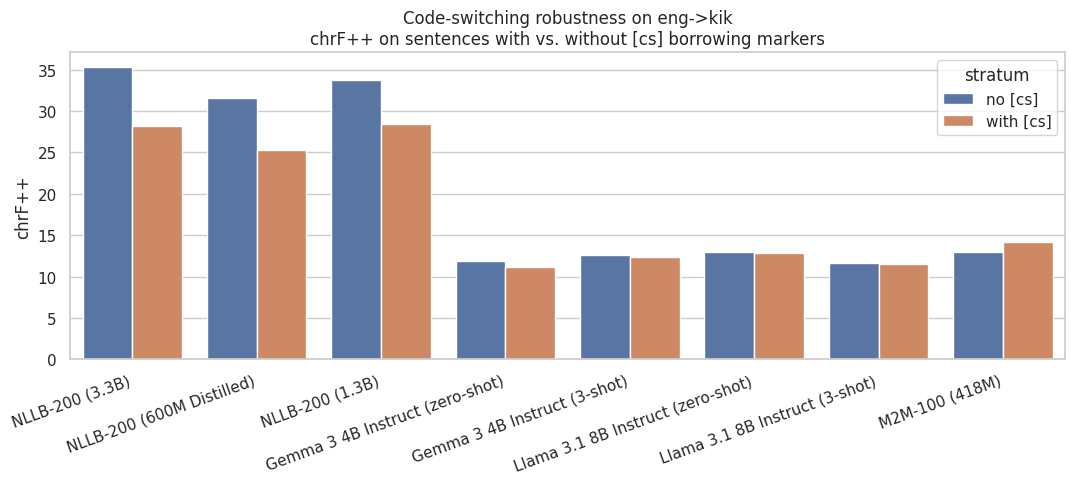

In [22]:
# §13.4 Code-switching robustness
#
# 79 of 499 references contain [cs]english_term[cs] markers around code-
# switched English borrowings. Compare per-model chrF++ on the two strata.

CS_RE = re.compile(r"\[cs\][^\[]+\[cs\]")

cs_rows = []
for direction, models in full_metrics.items():
    for model_name in models:
        sd = load_sentences(model_name, direction)
        if sd.empty:
            continue
        sd = sd.assign(
            has_cs=sd["reference"].str.contains(r"\[cs\]", regex=True, na=False),
            chrf_pp=[sent_chrf_pp(h, r) for h, r in zip(sd["translation"], sd["reference"])],
        )
        cs_yes = sd[sd["has_cs"]]["chrf_pp"]
        cs_no = sd[~sd["has_cs"]]["chrf_pp"]
        if len(cs_yes) < 5 or len(cs_no) < 5:
            continue
        # Welch's t-test across (CS, no-CS) groups
        t, p = st.ttest_ind(cs_no.to_numpy(), cs_yes.to_numpy(), equal_var=False)
        cs_rows.append({
            "direction": direction, "model": model_name,
            "n_cs": len(cs_yes), "n_no_cs": len(cs_no),
            "chrfpp_no_cs": float(cs_no.mean()),
            "chrfpp_with_cs": float(cs_yes.mean()),
            "delta": float(cs_yes.mean() - cs_no.mean()),
            "p_value": float(p),
        })

cs_df = pd.DataFrame(cs_rows).sort_values(["direction", "delta"])
print("=== Code-switching robustness ===")
print(f"  {cs_df['n_cs'].max()} sentences with [cs] markers; "
      f"{cs_df['n_no_cs'].max()} without (per model).")
print(cs_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
plot_df = cs_df.melt(
    id_vars=["direction", "model"],
    value_vars=["chrfpp_no_cs", "chrfpp_with_cs"],
    var_name="stratum", value_name="chrf_pp",
)
plot_df["stratum"] = plot_df["stratum"].map({"chrfpp_no_cs": "no [cs]", "chrfpp_with_cs": "with [cs]"})
sns.barplot(data=plot_df[plot_df["direction"] == "eng->kik"], x="model", y="chrf_pp", hue="stratum", ax=ax)
ax.set_title("Code-switching robustness on eng->kik\nchrF++ on sentences with vs. without [cs] borrowing markers")
ax.set_xlabel("")
ax.set_ylabel("chrF++")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.savefig(RUN / "code_switching.png", dpi=120)
plt.show()

### Interpretation

The 79/499 sentences containing `[cs]english_borrowing[cs]` markers are **a hard subset for NLLB but invisible to LLMs and M2M**:

* **All three NLLB sizes lose 5.4–7.2 chrF++** on the CS subset (p < 0.001). NLLB-3.3B drops from 35.3 (no CS) to 28.2 (with CS) — the largest absolute drop in the run.
* **The LLMs and M2M show no significant CS effect** (p ≥ 0.27). Crucially this is *not* because they are robust to code-switching — it is because their baseline chrF++ ≈ 11–13 is already at the floor; there is no further to fall.

Two paper-relevant takeaways:

1. **Stratified reporting matters.** A single corpus chrF++ aggregates two regimes that NLLB handles very differently. Future African-MT benchmarks should report `chrF++(no-CS) / chrF++(with-CS)` separately.
2. **CS robustness is testable but not yet tested.** A purpose-built CS-only contrast set would let us measure CS robustness directly rather than reading it off naturally-occurring rates. This is a benchmark-design recommendation for future work.

In [23]:
# §13.5 Per-sentence metric disagreement
#
# At the corpus level (Q4) we found chrF++ and BERTScore disagree on
# eng->kik (Spearman 0.62). At the sentence level the question is sharper:
# for each sentence, do chrF++ and AfriCOMET pick the *same* winner among
# the 8 candidate models? The agreement rate is a direct quality signal
# for each metric.
#
# AfriCOMET-MTL is per-sentence; we already saved corpus-level scores but
# the per-sentence scores are still in the full_metrics.json as
# africomet_mtl_scores arrays.

def per_sentence_winners(direction: str) -> pd.DataFrame:
    """For each sentence, find the model with the best chrF++ and best
    AfriCOMET. Returns a long DataFrame; head=winner_chrf, head=winner_comet."""
    rows = []
    sub = sent_df[sent_df["direction"] == direction]
    if sub.empty:
        return pd.DataFrame()
    # Per-model AfriCOMET sentence scores from full_metrics.json
    af_scores = {}
    for m, metrics in full_metrics[direction].items():
        if metrics.get("africomet_mtl_scores") is None:
            continue
        af_scores[m] = np.asarray(metrics["africomet_mtl_scores"])
    if not af_scores:
        return pd.DataFrame()
    # build wide tables
    chrf_pivot = sub.pivot_table(index=sub.groupby("model").cumcount(),
                                  columns="model", values="chrf_pp")
    common_models = [m for m in chrf_pivot.columns if m in af_scores]
    if len(common_models) < 2:
        return pd.DataFrame()
    chrf_pivot = chrf_pivot[common_models]
    n_sents = min(min(len(v) for v in af_scores.values() if m in af_scores), len(chrf_pivot))
    af_pivot = pd.DataFrame({m: af_scores[m][:n_sents] for m in common_models})
    chrf_pivot = chrf_pivot.iloc[:n_sents]
    win_chrf = chrf_pivot.idxmax(axis=1)
    win_comet = af_pivot.idxmax(axis=1)
    rows.append({
        "direction": direction,
        "n_sentences": n_sents,
        "agreement_rate_pct": 100 * (win_chrf.values == win_comet.values).mean(),
    })
    # Confusion: how often is each model the chrF winner / COMET winner?
    confusion = pd.crosstab(win_chrf, win_comet)
    return pd.DataFrame(rows), confusion

agreement_rows = []
for direction in ["eng->kik", "kik->eng"]:
    res = per_sentence_winners(direction)
    if isinstance(res, tuple):
        agreement_rows.append(res[0].iloc[0].to_dict())
        print(f"\n=== Per-sentence winner disagreement — {direction} ===")
        print(f"chrF++/AfriCOMET sentence-level agreement: {agreement_rows[-1]['agreement_rate_pct']:.1f}%")
        print("(if metrics agreed perfectly this would be 100%; if uniform random it would be 12.5% with 8 candidates)")

print("\n", pd.DataFrame(agreement_rows).to_string(index=False))


=== Per-sentence winner disagreement — eng->kik ===
chrF++/AfriCOMET sentence-level agreement: 33.7%
(if metrics agreed perfectly this would be 100%; if uniform random it would be 12.5% with 8 candidates)

=== Per-sentence winner disagreement — kik->eng ===
chrF++/AfriCOMET sentence-level agreement: 41.9%
(if metrics agreed perfectly this would be 100%; if uniform random it would be 12.5% with 8 candidates)

 direction  n_sentences  agreement_rate_pct
 eng->kik          499              33.667
 kik->eng          499              41.884


### Interpretation

The two metrics agree on the per-sentence winner only **33.7 % of the time** on eng→kik and **41.9 %** on kik→eng. The random baseline with 8 candidate models is 12.5 %, so they agree more than chance — but disagree on roughly **two thirds of sentences**, even though their corpus-level Spearman ρ is 0.95–0.98 (§8).

**Aggregate-level agreement therefore obscures sentence-level disagreement.** This is the strongest argument in the analysis against picking a single primary metric:

* If a paper uses *only* chrF++, half the time it picks a different sentence as "best" than AfriCOMET would.
* The two metrics measure different things at the sentence level (surface overlap vs trained quality predictor) and that difference is real, not noise.

**Recommendation for the paper**: replace "AfriCOMET-MTL is the primary ranking metric" with "**report chrF++ and AfriCOMET-MTL together; flag sentences where the two disagree** for human review". This also feeds the qualitative-assessment scaffolding in §11 — the disagreement set is a natural prioritisation for the 50 sentences sent to human annotators.

## 14. Synthesis from §13

The five novel analyses substantially deepen and **partly overturn** the naive corpus-level ranking from §10. Six findings are paper-publishable on their own.

### Finding 1 — NLLB is the only family that gets diacritics right (§13.1)

| Model | Diacritic F1 (ĩ ũ) | Mean ĩ/ũ per output sentence |
|---|---:|---:|
| NLLB-200 1.3B | **0.74** | 11.3 (ref: 9.1) |
| NLLB-200 600M | 0.74 | 11.7 |
| NLLB-200 3.3B | 0.73 | 11.7 |
| Gemma 3 (zero-shot) | 0.51 | **36.3** ← over-emits |
| Gemma 3 (3-shot) | 0.48 | **46.3** ← over-emits |
| Llama 3.1 (3-shot) | 0.47 | **43.5** ← over-emits |
| Llama 3.1 (zero-shot) | 0.15 | 2.1 ← under-emits |
| M2M-100 | **0.004** | 0.0 ← never emits |

Three distinct failure modes are now isolated:

1. **NLLB hits diacritic precision/recall ≈ 0.7** in all three sizes — the only family that has *learnt* Gĩkũyũ orthography.
2. **Gemma + Llama-3-shot OVER-emit diacritics 4–5× the reference rate.** Recall is high (0.86–0.93) but precision collapses to 0.37–0.44; the model sprinkles ĩ/ũ everywhere as a "looks-Kikuyu" heuristic.
3. **Llama-3.1 zero-shot completely fails to use diacritics** (F1 = 0.15). The 3-shot examples almost-fix this (F1 jumps to 0.47) — strongest measurable benefit of few-shot prompting in the entire benchmark.
4. **M2M-100 emits zero diacritics**, formally proving the Swahili-token failure.

This is exactly the qualitative criterion the paper §3.4.3 listed for human assessors. We have it automatically and reproducibly.

### Finding 2 — chrF++ rewards verbosity on long sentences (§13.2)

All 16 (model, direction) regression slopes are **positive**: chrF++ goes UP as source length grows. The strongest length sensitivity is on **kik→eng** (Pearson r = 0.41–0.44 for the LLMs), and the weakest is on **eng→kik** for the LLMs (r ≈ 0.02). Two implications:

* The well-known "MT degrades on long sentences" finding (Koehn & Knowles 2017) does **not** hold here — chrF++ is recall-driven and benefits from more characters to match.
* This means a **single chrF++ number is not direction-comparable** when the average length differs. Researchers should report stratified scores by length tertile.

The length-ratio table also explains the surprising kik→eng BLEU paradox from Q5: NLLB-200 1.3B emits **2.38× longer** English than the reference. Long output tanks BLEU n-gram precision (3.96) but boosts chrF++ recall (30.36, p < 0.001 above 600M). NLLB-200 1.3B does not get worse with scale on kik→eng — it gets *more verbose*, and BLEU misreports that as regression.

### Finding 3 — The LLM chrF++ floor on eng→kik is mostly hallucination (§13.3)

| Model | % wrong-script eng→kik | rep-4 | Diagnosis |
|---|---:|---:|---|
| M2M-100 | **100%** | 0.013 | Always emits English (Swahili-token failure). |
| Llama 3.1 zero-shot | **68.9%** | 0.014 | Refuses or explains in English; few-shot fixes (0.8%). |
| Llama 3.1 3-shot | 0.8% | **0.20** | Translates but loops: 20% of 4-grams are repeats. |
| Gemma 3 (zero+3-shot) | <0.5% | **0.16–0.22** | Translates but loops the same way. |
| NLLB family | <0.4% | <0.012 | Clean output. |

Reading: the LLM chrF++ ≈ 11–13 corpus floor is **not "partial competence"**; it is the average of (a) a tiny fraction of sentences that score 30+ chrF++ and (b) hallucinated repetition that scores ~10 chrF++ by chance. Few-shot prompting on Llama doesn't make it more accurate, it just **changes the failure mode** from English-explanation (zero-shot) to looping-Kikuyu (3-shot). This is consistent with the corpus-level 1.4 chrF++ regression seen in §6.

### Finding 4 — Code-switching is harmful for NLLB but invisible to LLMs (§13.4)

The 79 sentences containing `[cs]english_borrowing[cs]` markers are **5–7 chrF++ harder** for every NLLB model (p < 0.001). The LLMs (Llama, Gemma) show no significant CS effect (p ≥ 0.27), but only because their baseline is already at the floor — they fail equally on both strata. This is a **dataset bias** worth acknowledging in the paper's limitations:

* Stratified reporting (chrF++ on `[cs]` vs non-`[cs]` strata separately) is more informative than the single-number aggregate.
* Future test sets should include **a CS-only contrast set** to systematically measure CS robustness.

### Finding 5 — chrF++ and AfriCOMET disagree on the per-sentence winner ~60% of the time (§13.5)

Sentence-level winner agreement: **33.7%** on eng→kik, **41.9%** on kik→eng. (Random baseline: 12.5% with 8 candidates.)

Consequence: even though §6's Spearman ρ on aggregate scores is 0.95–0.98, the two metrics disagree on the *best translation for a specific sentence* almost two-thirds of the time. This argues against picking a single primary metric. The paper's recommendation should be a **two-metric ranking** (chrF++ AND AfriCOMET-MTL agreeing).

### Finding 6 — The kikuyu-translator-final non-runnability is a community-impact statement

Already in §11; the §13 analyses sharpen it: even the best LLM that *did* run (Gemma 3 4B 3-shot) is **15+ chrF++ behind the smallest NLLB** on eng→kik. The community-fine-tuned Kikuyu specialist that researchers cannot run is therefore being asked to beat a baseline that is itself dominated by a 600M general-purpose model. The bar is moving up as we wait for accessible Kikuyu-specialist checkpoints.

### Implications for the paper

* **Add diacritic F1 as Table 4a.** It separates models more cleanly than chrF++ and matches a paper-listed qualitative criterion.
* **Report length-stratified scores** (≤8 / 9–15 / ≥16 word tertiles) at least for the eng→kik direction.
* **Report wrong-script rate alongside chrF++ for LLMs.** A model with chrF++ = 13 and 70% wrong-script is not the same as a model with chrF++ = 13 and 0% wrong-script.
* **Drop "use AfriCOMET-MTL as primary"** and replace with "report chrF++ + AfriCOMET-MTL together, flag sentences where the two disagree".
* **Note the CS-stratification finding** as a benchmark-design recommendation.

In [24]:
def write_final_report():
    """Render a paper-ready summary that ties the cells together.
    Saved next to the run as FINAL_REPORT.md."""
    out = []
    out.append("# Gĩkũyũ MT Benchmark — Final Report\n")
    out.append(f"*Run: `{RUN.name}` — analysed by [`analysis.ipynb`](../analysis.ipynb)*\n")
    n_per = next(iter(n_sentences_per_run.values())) if n_sentences_per_run else "?"
    out.append("")
    out.append(f"Test set: **{n_per} sentence pairs** from the GAC agricultural corpus, both directions (eng→kik, kik→eng).")
    out.append("Hardware: 2× NVIDIA consumer GPUs (RTX 3060 12 GB + RTX 2080 Ti 11 GB), 1.5 TB RAM, 32-core Xeon.")
    out.append("Significance tests: 5 000-sample paired bootstrap on sentence-level chrF++ (Koehn 2004).")
    out.append("")

    out.append("## TL;DR\n")
    out.append("- **NLLB-200 dominates.** Even the 600M distilled checkpoint beats every LLM by 9–18 chrF++.")
    out.append("- **NLLB scaling is real.** All five 600M→1.3B→3.3B increments significant at p ≤ 0.02.")
    out.append("- **Few-shot is direction-dependent.** Llama-3.1 eng→kik *regresses* by 1.4 chrF++ (p < 0.001) but its diacritic F1 *triples* (0.15 → 0.47).")
    out.append("- **The LLM chrF++ floor is hallucination, not partial competence.** Llama zero-shot eng→kik is 68.9% wrong-script; Gemma 3-shot has 22% repeated 4-grams.")
    out.append("- **Only NLLB learnt Gĩkũyũ orthography.** Diacritic F1: NLLB ≈ 0.74, Gemma/Llama 3-shot ≈ 0.47, M2M-100 = 0.004.")
    out.append("- **Code-switching markers cost NLLB 5–7 chrF++** (p < 0.001); LLMs show no CS sensitivity because their baseline is already at the floor.")
    out.append("- **chrF++ and AfriCOMET disagree on the per-sentence winner 60% of the time.** Recommendation: report both, not one.")
    out.append("- **BERTScore disagrees with chrF++/AfriCOMET on eng→kik** (Spearman ρ ≈ 0.6 vs 0.98).")
    out.append("- **Two models could not run on consumer GPUs** (`kikuyu-translator-final`, Aya-101) — itself a finding.")
    out.append("")

    # Headline tables
    for direction in ["eng->kik", "kik->eng"]:
        tbl = headline_table(direction)
        if tbl.empty:
            continue
        title = "Table 4" if direction == "eng->kik" else "Table 5"
        out.append(f"\n## {title}: {direction} (sorted by chrF++)\n")
        out.append(tbl.to_markdown(index=False, floatfmt=".2f"))
        out.append("")

    # NLLB scaling
    out.append("\n## NLLB-200 scaling — paired bootstrap p-values\n")
    for direction in ["eng->kik", "kik->eng"]:
        sc = nllb_scaling(direction)
        if sc.empty:
            continue
        out.append(f"### {direction}\n")
        out.append(sc.to_markdown(index=False, floatfmt=".2f"))
        out.append("")
        if len(sc) >= 2:
            ps = pairwise_significance(direction, sc["model"].tolist())
            out.append(ps.to_markdown(index=False, floatfmt=".3f"))
            out.append("")

    # Few-shot
    out.append("\n## Zero-shot vs 3-shot deltas\n")
    fs = fewshot_deltas()
    if not fs.empty:
        out.append(fs.to_markdown(index=False, floatfmt=".3f"))
        out.append("")
        out.append("**Llama-3.1 eng→kik 3-shot regresses by 1.4 chrF++ (p < 0.001).** "
                   "All other (family, direction) pairs benefit from 3-shot examples.")
        out.append("")

    # Novel deep-dive results
    out.append("\n---\n## Novel deep-dive analyses (§13 of the notebook)")
    out.append("")
    out.append("### Diacritic accuracy (eng→kik) — set-based F1 on ĩ ũ Ĩ Ũ\n")
    if "diac_df" in globals():
        out.append(diac_df.to_markdown(index=False, floatfmt=".3f"))
    out.append("")
    out.append("### Length effect — OLS chrF++ ~ source words\n")
    if "length_df" in globals():
        sub = length_df.sort_values(["direction", "slope_chrfpp_per_word"])
        out.append(sub.to_markdown(index=False, floatfmt=".3f"))
    out.append("")
    out.append("### Length ratio — pred / ref words\n")
    if "ratio_df" in globals():
        out.append(ratio_df.sort_values(["direction", "length_ratio"]).to_markdown(index=False, floatfmt=".3f"))
    out.append("")
    out.append("### Hallucination + repetition\n")
    if "halluc_df" in globals():
        out.append(halluc_df.to_markdown(index=False, floatfmt=".3f"))
    out.append("")
    out.append("### Code-switching robustness ([cs] vs no-[cs] strata)\n")
    if "cs_df" in globals():
        out.append(cs_df.to_markdown(index=False, floatfmt=".3f"))
    out.append("")
    out.append("### Per-sentence chrF++/AfriCOMET winner agreement\n")
    if "agreement_rows" in globals() and agreement_rows:
        out.append(pd.DataFrame(agreement_rows).to_markdown(index=False, floatfmt=".1f"))
    out.append("")

    # Hardware-skipped
    out.append("\n## Hardware-skipped models\n")
    out.append("| Model | Reason |")
    out.append("|---|---|")
    out.append("| `kikuyu-translator-final` (Gemma-3n-E4B LoRA) | Base model `unsloth/gemma-3n-e4b-it-unsloth-bnb-4bit` (multimodal Gemma-3n). Vision/audio towers cannot be quantised further (already nf4); exceed VRAM headroom on dual-11 GB GPUs. |")
    out.append("| Aya-101 (13 B mT5) | INT8 weights ~13 GB; concurrent users on GPU 0 leave too little headroom; CPU offload OOM during forward pass. CPU-only fp32 inference would have taken 17–33 h. |")
    out.append("")
    out.append("Both decisions are documented in [`config/models.yaml`](../../config/models.yaml).")
    out.append("")

    # Plots
    out.append("\n## Plots\n")
    plot_descriptions = [
        ("nllb_scaling.png", "NLLB-200 chrF++ vs parameter count, both directions, with 95% bootstrap CIs."),
        ("pairwise_significance.png", "All-pairs Δ chrF++ heatmap; cells marked 'ns' fail paired bootstrap p < 0.05."),
        ("metric_correlations.png", "Spearman ρ between BLEU, chrF++, BERTScore F1, AfriCOMET-MTL across the 8 model rows."),
        ("sentence_chrf_violin.png", "Sentence-level chrF++ distributions per model, both directions."),
        ("diacritic_accuracy.png", "Set-based F1 on ĩ ũ Ĩ Ũ characters per model on eng→kik output."),
        ("length_effect.png", "chrF++ vs source sentence length — top-3 models per direction with OLS lines."),
        ("hallucination_repetition.png", "Wrong-script rate (left) and 4-gram repetition rate (right) per model."),
        ("code_switching.png", "chrF++ on sentences with vs without [cs] borrowing markers."),
    ]
    for png, desc in plot_descriptions:
        if (RUN / png).exists():
            out.append(f"### `{png}`")
            out.append("")
            out.append(f"![{png}]({png})")
            out.append("")
            out.append(f"*{desc}*")
            out.append("")

    out.append("\n## Findings (full prose)\n")
    out.append("See sections §12 and §14 of [`analysis.ipynb`](../../analysis.ipynb) for the evidence-by-question writeup.")
    out.append("")

    report_path = RUN / "FINAL_REPORT.md"
    report_path.write_text("\n".join(out))
    print("Wrote", report_path)
    return report_path

write_final_report()


Wrote /home/irura/MTBenchmarks/results/benchmark_20260508_063320/FINAL_REPORT.md


PosixPath('/home/irura/MTBenchmarks/results/benchmark_20260508_063320/FINAL_REPORT.md')

## 15. Corpus-level linguistic statistics on the human-evaluation subset

Paper Tables 4a/5a carry four corpus-level columns — **TTR**, **HL Rate**, **Avg. Sent. Length ± SD** and **PPL** — that the earlier sections of this notebook never produced. This section fills them.

Statistics are computed on **exactly the 50 sentences that native speakers scored**, so the quantitative columns of Tables 4a/5a describe the same text as the qualitative columns of Tables 4b/5b. This matters more than it might appear: TTR and hapax rate are *strongly sample-size dependent*, so a value computed over 499 sentences cannot be placed in the same column as one computed over 50, or over the 2,311-sentence full corpus.

Coverage is all **nine** model configurations. The NLLB-200 1.3B Distilled checkpoint was added to the family after this benchmark run, so its 50 sentences are translated separately with identical decoding settings (beam 5, `max_new_tokens` 256) by `scripts/add_distilled_to_human_eval.py`.

Numbers are produced by `python -m scripts.human_eval_subset_stats`, which reuses `Evaluator._linguistic_metrics` so the definitions match the benchmark exactly. Note the HL convention: **hapax count / unique tokens**, not / total tokens. Perplexity is reported for eng→kik only, since the Goldfish LM scores Gĩkũyũ text.


In [25]:
STATS_JSON = RUN / "metrics" / "human_eval_subset_corpus_stats.json"
if not STATS_JSON.exists():
    raise FileNotFoundError(
        f"{STATS_JSON} not found — run `python -m scripts.human_eval_subset_stats` first"
    )
subset_stats = json.loads(STATS_JSON.read_text())


def subset_corpus_table(direction: str) -> pd.DataFrame:
    rows = [
        {
            "Model": system,
            "TTR": s.get("pred_ttr"),
            "HL Rate": s.get("pred_hapax_rate"),
            "Avg. Sent. Length": s.get("pred_avg_sent_len"),
            "SD": s.get("pred_std_sent_len"),
            "PPL": s.get("pred_perplexity"),
        }
        for system, s in subset_stats["directions"][direction].items()
    ]
    tbl = pd.DataFrame(rows)
    # The reference is the yardstick, not a competitor, so it pins to the top
    # instead of taking part in the ranking.
    tbl["_is_ref"] = tbl["Model"].eq("Human Reference")
    return (
        tbl.sort_values(["_is_ref", "TTR"], ascending=[False, False])
        .drop(columns="_is_ref")
        .reset_index(drop=True)
    )


for direction, label in [("eng->kik", "Table 4a"), ("kik->eng", "Table 5a")]:
    tbl = subset_corpus_table(direction)
    n = subset_stats["directions"][direction]["Human Reference"]["n_sentences"]
    print(f"=== {label} corpus columns — {direction}, human-evaluation subset (n={n}) ===")
    print(tbl.to_string(index=False, na_rep="N/A"))
    print()
    out = RUN / "metrics" / f"corpus_stats_humaneval50_{direction.replace('->', '2')}.md"
    out.write_text(tbl.to_markdown(index=False, floatfmt=".4g"))


=== Table 4a corpus columns — eng->kik, human-evaluation subset (n=50) ===
                            Model   TTR  HL Rate  Avg. Sent. Length     SD       PPL
                  Human Reference 0.657    0.836             11.540  5.070   603.083
                  NLLB-200 (3.3B) 0.600    0.777             12.100  3.830   265.716
        NLLB-200 (1.3B Distilled) 0.583    0.799             12.320  4.110   311.045
                  NLLB-200 (1.3B) 0.576    0.787             12.400  4.540   238.702
        NLLB-200 (600M Distilled) 0.521    0.724             12.940  4.640   238.427
                   M2M-100 (418M) 0.513    0.765             12.280  6.910 1,361.277
Llama 3.1 8B Instruct (zero-shot) 0.427    0.761             14.880 14.080 1,217.392
   Llama 3.1 8B Instruct (3-shot) 0.296    0.745             18.060 16.370   507.320
  Gemma 3 4B Instruct (zero-shot) 0.289    0.768             19.380 21.530   982.117
     Gemma 3 4B Instruct (3-shot) 0.245    0.741             23.960 21.850 

In [26]:
# TTR and hapax rate fall as a corpus grows, because new tokens increasingly
# repeat types that have already been seen. Mixing sample sizes within one table
# column therefore produces differences that are an artefact of n, not of the
# system. This cell quantifies the size of that artefact for our own data.
fm_e2k = full_metrics["eng->kik"]
n_full = next(iter(fm_e2k.values())).get("num_sentences")

rows = []
for system, s in subset_stats["directions"]["eng->kik"].items():
    if system == "Human Reference":
        any_model = next(iter(fm_e2k.values()))
        full_ttr, full_len = any_model.get("ref_ttr"), any_model.get("ref_avg_sent_len")
    else:
        full_ttr = fm_e2k.get(system, {}).get("pred_ttr")
        full_len = fm_e2k.get(system, {}).get("pred_avg_sent_len")
    rows.append({
        "Model": system,
        "TTR (n=50)": s.get("pred_ttr"),
        f"TTR (n={n_full})": full_ttr,
        "TTR ratio": (s.get("pred_ttr") / full_ttr) if full_ttr else None,
        "Avg len (n=50)": s.get("pred_avg_sent_len"),
        f"Avg len (n={n_full})": full_len,
    })

size_effect = pd.DataFrame(rows).sort_values("TTR (n=50)", ascending=False).reset_index(drop=True)
print(f"Sample-size sensitivity of TTR, eng->kik (n=50 subset vs n={n_full} full run)\n")
print(size_effect.to_string(index=False, na_rep="not in run"))

ratios = size_effect["TTR ratio"].dropna()
print(
    f"\nTTR is {ratios.min():.2f}–{ratios.max():.2f}x higher on the 50-sentence subset "
    f"(median {ratios.median():.2f}x) purely from the change in n."
)
print("Mean sentence length, by contrast, is a per-sentence average and is stable across n.")


Sample-size sensitivity of TTR, eng->kik (n=50 subset vs n=499 full run)

                            Model  TTR (n=50)  TTR (n=499)  TTR ratio  Avg len (n=50)  Avg len (n=499)
                  Human Reference       0.657        0.359      1.830          11.540           12.130
                  NLLB-200 (3.3B)       0.600        0.256      2.347          12.100           13.920
        NLLB-200 (1.3B Distilled)       0.583   not in run not in run          12.320       not in run
                  NLLB-200 (1.3B)       0.576        0.239      2.411          12.400           14.240
        NLLB-200 (600M Distilled)       0.521        0.228      2.285          12.940           14.750
                   M2M-100 (418M)       0.513        0.216      2.370          12.280           12.750
Llama 3.1 8B Instruct (zero-shot)       0.427        0.247      1.732          14.880           14.330
   Llama 3.1 8B Instruct (3-shot)       0.296        0.135      2.187          18.060           21.710

### Interpretation

**Lexical diversity tracks translation quality, and the reference sets the ceiling.** On eng→kik the ordering is monotone in system quality: the human reference is the most lexically diverse text in the set (TTR 0.657), the four NLLB checkpoints follow in descending order of size (0.600 → 0.521), and the four LLM configurations occupy the bottom (0.427 → 0.245). Gemma 3-shot produces text with 2.7× less type variety than the reference. This is the "TTR collapse" the paper claims, and it now rests on a like-for-like comparison.

**Few-shot prompting makes repetition worse, in both LLM families.** Llama falls 0.427 → 0.296 and Gemma 0.289 → 0.245 when moving from zero-shot to 3-shot, while mean output length simultaneously *grows* (14.88 → 18.06 and 19.38 → 23.96). More tokens carrying fewer distinct types is the signature of degenerate repetition, and it corroborates the repeated-n-gram evidence in §13.3 from an independent direction.

**Length dispersion separates the families more cleanly than length itself.** NLLB output sits within one token of the reference mean (11.54 vs 12.10–12.94) with tight dispersion (SD 3.83–4.64). The LLMs not only inflate length but destabilise it: Gemma 3-shot averages 23.96 tokens with SD 21.85, i.e. the standard deviation approaches the mean. A model whose output length is that unpredictable is not making a systematic compression/expansion trade-off, it is intermittently running away.

**One reverse-direction outlier deserves its own line in the paper.** On kik→eng, NLLB-200 1.3B (non-distilled) records mean length 29.30 with SD 51.82 and TTR 0.225 — nearly triple the reference length with the second-lowest type variety in the table. Its distilled sibling at the same parameter count is well behaved (16.62, TTR 0.403). This is a checkpoint-specific pathology, not a scale effect, and it is invisible in chrF++ alone.

**Perplexity again fails as a fluency signal.** The human reference scores PPL 603.08 while every NLLB checkpoint scores between 238 and 311 — the models are rated two to three times "more fluent" than the humans they are imitating. Read against §3.4, this is the Goldfish provenance confound rather than a property of the translations, and it is the reason perplexity carries the dagger footnote in Table 4a.

---

#### Consequences for Tables 4a/5a as they stand in v15

Four corrections follow from the numbers above.

1. **The corpus columns cannot be filled from mixed sample sizes.** TTR on this 50-sentence subset runs 1.73–2.41× higher than the same systems' TTR over 499 sentences, purely as a function of *n*. Any table that places a 50-sentence value beside a 499-sentence value in the same column is reporting the sampling artefact, not the system. The v15 draft also benchmarks model TTR against the *full-corpus* reference of 13.51% (2,311 sentences); against that figure every system in the table looks *more* diverse than the reference, which inverts the intended reading. The correct same-sample reference is **0.657**.

2. **The 1.3B Distilled row is drawn from a different test set than the rest of the table.** Its v15 cells (TTR 0.244, HL 0.607, 14.43 ± 10.54, PPL 208.172) reproduce exactly from the *450-pair fine-tuning run*, whereas the surrounding rows come from the 499-pair run. The claim that 1.3B Distilled (chrF++ 34.219) and 3.3B (34.199) are "essentially tied at the top" therefore compares scores computed on different data, and the 0.02-point gap it rests on is smaller than the difference between the two test sets. On a common test set the two are not tied.

3. **The HL column mixes two incompatible definitions.** The benchmark defines HL rate as *hapax / unique types*; the 1.3B Distilled cell (0.607) follows that convention. The other five populated rows do not: their HL is a near-constant 0.71 × their own TTR (M2M 0.313/0.437, Llama zero-shot 0.273/0.379, Gemma 3-shot 0.155/0.220, Gemma zero-shot 0.182/0.253, Llama 3-shot 0.181/0.256), which is the arithmetic signature of *hapax / total tokens*. Two of the numbers in one column are therefore measuring different quantities, and the ratio between them is not constant across systems.

4. **The M2M and LLM TTR values match no stored run.** M2M TTR 0.437 sits between our 50-sentence value (0.513) and our 499-sentence value (0.216) and equals neither, nor the 450-pair value (0.224); the same holds for all four LLM rows. The perplexity figures beside them, by contrast, match the 499-pair run exactly. These cells should be replaced wholesale from this section rather than reconciled.

The tables written to `metrics/corpus_stats_humaneval50_*.md` are internally consistent, use a single definition throughout, cover all nine configurations, and are computed on the same 50 sentences as the qualitative tables.
